# Notebook 3 of 3 -- Pretest, Prioritize, Personalize: calibrated LLM pretests, RATE for setter calls, KPT for templates

This is the third and final notebook in a three-part series exploring statistically rigorous marketing
automation for a realistic small-business scenario: a YouTube-focused agency helping US real estate agents
("realtors") get more views, leads, and closed deals, going "AI first" for sales & marketing automation.
Notebook 2 replicated a plausible current outbound system on synthetic data with **known latent truth**
(a fit score, a randomized setter-call pilot, a single email template for everyone) and audited it
honestly. This notebook picks up the three methods the **pretest -> prioritize -> personalize** pipeline is
built around, each evaluated against the same known latent truth:

1. **Pretest** (Section 2): can a DeepSeek persona stand in for a human realtor when comparing two email
 templates, before spending pilot budget on the comparison? Surrogacy framework, arXiv:2606.17165.
2. **Prioritize** (Section 3): does the fit score the setter is handed today actually track *call uplift*,
 not just baseline booking odds? RATE, arXiv:2111.07966.
3. **Personalize** (Section 4): does giving each realtor their own best email template beat sending everyone
 the single best template? KPT, arXiv:2607.08951.
4. **Cost** (Section 5) and a **"Not built yet"** list of what none of the three papers cover.

**Important framing, repeated from Notebook 2:** this three-notebook series is a *learning
project*, not a record of prior production experience. The **pretest -> prioritize -> personalize**
pipeline is *my own design*, not a claim sourced from the three papers -- none of them were written for
outbound sales, and none of them analyze chaining the three methods together (Section 5). Every threshold
and number below is either quoted from one of the three source papers, or labeled **"derived here"** if it
is not. Toy simulation numbers are kept visibly separate from paper numbers throughout.

**Recap of Notebook 2's executed numbers** (used below without re-deriving them):

| Quantity | Notebook 2's value |
|---|---|
| True call (setter) ATE | ~6.2pp; within-segment uplift SD ~4.5pp |
| Best single email template | `generic_case_study` (template 0), gap to 2nd-best 1.22pp |
| True personalization psi (depth<=2 policy, outcome `positive_reply`) | 0.591pp |
| `do_not_disturb_media_team` segment | the one place template 2 (`video_audit_teaser`) beats template 0: ~13.5% vs ~10% reply |
| LLM fit score vs true uplift | weakly related (Spearman ~0.18); AUC for `booked_call` ~0.58; top-quintile of the *rule* score has **negative** true uplift |
| `pilot_leads.csv` | 3,000 rows, 31 columns; first 600 rows are the LLM-scored subset (`llm_fit` non-null only there); `W` (setter call, pi=0.5), `template` in {0,1,2} (pi=1/3) |
| `new_leads.csv` | 400 fresh, never-contacted leads for this notebook's LLM pretest |

**Power warning (acted on below):** a 3-arm reply contrast at ~1,000 leads per arm has
SE ~= 1.3pp on the reply rate -- larger than psi = 0.59pp. Both the RATE evaluation of the fit score (600
LLM-scored leads) and the KPT personalization test (3,000-lead pilot) are expected to be **underpowered** at
this pilot's size. Section 4 adds a **derived-here power-vs-pilot-size analysis** so the honest answer is not
just "no effect" but "here is how big a pilot the agency would actually need." Underpowered results are
reported as **"no evidence at this pilot size,"** never as "no effect," and a tiny-n result is never marked
PASS just because a self-check's arithmetic happens to clear its threshold.

## 1. Reload Notebook 2's pipeline exactly

Every reuse-tagged code cell from `02_project_walkthrough_part1.ipynb` is executed here verbatim, via
`nbformat` + `exec(compile(...), globals)`, in the order it appears in that notebook -- this notebook does
**not** re-implement the lead generator, the email templates, the DeepSeek client, or the outcome model. The
only adjustment made here is stripping IPython "%magic" lines (like `%matplotlib inline`) before `compile`,
since the plain-Python `compile` builtin cannot parse them; `%matplotlib inline` is invoked directly
instead, once, below. Reusing the DeepSeek client's on-disk cache means every lead that was already scored
in Notebook 2 (the 600-lead LLM fit-score subset) should come back as a cache hit here -- **0 live calls** to
reconstruct Notebook 2's pilot.

In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
import nbformat as _nbformat
from pathlib import Path as _Path

_NB2_PATH = _Path.cwd() / "02_project_walkthrough_part1.ipynb"
_nb2 = _nbformat.read(_NB2_PATH, as_version=4)
_reuse_cells = [c for c in _nb2.cells if c.cell_type == "code" and "reuse" in c.metadata.get("tags", [])]
print(f"[S1.0] found {len(_reuse_cells)} reuse-tagged code cells in Notebook 2")

# Run each reuse cell through the live IPython kernel (get_ipython().run_cell), not a bare exec()
# of magic-stripped source -- run_cell processes magics (e.g. %matplotlib inline) the same way
# Notebook 2 itself does, so this replay is byte-for-byte what NB2's own kernel would run, not an
# edited approximation of it (fix: the previous _strip_magics()+exec() approach
# silently deleted every magic line before running the cell, which is not "verbatim").
_ip = get_ipython()
for _i, _c in enumerate(_reuse_cells):
    _result = _ip.run_cell(_c.source)
    _result.raise_error()  # surface a reuse-cell failure immediately instead of masking it

print(f"[S1.1] executed all {len(_reuse_cells)} reuse cells; SEED={SEED}, MAX_LIVE_CALLS(NB2)={MAX_LIVE_CALLS}, "
      f"live_calls so far={LLM_STATS['live_calls']} (expect 0, smoke test cell should be a cache hit)")


[S1.0] found 7 reuse-tagged code cells in Notebook 2


[S1.1] executed all 7 reuse cells; SEED=20260917, MAX_LIVE_CALLS(NB2)=40, live_calls so far=0 (expect 0, smoke test cell should be a cache hit)


In [2]:
# Rebuild NB2's population, pilot, and new-leads exactly (same functions, same seeds), to
# confirm the reuse-cell reload reproduces Notebook 2's saved CSVs byte-for-byte, and that every
# LLM fit-score call needed to do so is a cache hit (0 live calls).
import hashlib

POPULATION = generate_leads(6000, SEED)

PILOT_N = 3000
LLM_SUBSET_N = 600
NEW_LEADS_N = 400

PILOT_POOL = select_pilot_pool(POPULATION, PILOT_N, seed=SEED + 100)
PILOT_POOL["rule_fit"] = PILOT_POOL.apply(rule_fit_score, axis=1)
LLM_SUBSET = PILOT_POOL.iloc[:LLM_SUBSET_N].copy()

_calls_before = LLM_STATS["live_calls"]
_llm_scores = score_leads_fit_llm(LLM_SUBSET, batch_size=20)
_calls_used_reload = LLM_STATS["live_calls"] - _calls_before

_llm_scores = _llm_scores.set_index("lead_id")
LLM_SUBSET = LLM_SUBSET.set_index("lead_id")
LLM_SUBSET["llm_status"] = _llm_scores["llm_status"]
LLM_SUBSET["llm_reason"] = _llm_scores["llm_reason"]
LLM_SUBSET["llm_fallback"] = LLM_SUBSET["llm_status"] != "ok"
LLM_SUBSET["llm_fit"] = np.where(
    LLM_SUBSET["llm_fallback"], LLM_SUBSET["rule_fit"], _llm_scores["llm_fit_raw"]
)
LLM_SUBSET = LLM_SUBSET.reset_index()

PILOT_POOL = PILOT_POOL.merge(
    LLM_SUBSET[["lead_id", "llm_fit", "llm_fallback", "llm_status", "llm_reason"]],
    on="lead_id", how="left",
)

PILOT_POOL = assign_pilot_treatment(PILOT_POOL, seed=SEED + 200)
_realized = draw_realized_outcomes(PILOT_POOL, PILOT_POOL["W"].to_numpy(), PILOT_POOL["template"].to_numpy(), seed=SEED + 201)
PILOT_POOL["booked_call"] = _realized["booked_call"]
PILOT_POOL["positive_reply"] = _realized["positive_reply"]

NEW_LEADS = generate_leads(NEW_LEADS_N, seed=SEED + 900)

print(f"[S1.2] live calls used to reproduce the 600-lead LLM fit-score subset = {_calls_used_reload} "
      f"(threshold 0, disk cache from Notebook 2 should cover every one) -> "
      f"{'PASS' if _calls_used_reload == 0 else 'FAIL'}")

def _csv_bytes(df):
    return df.to_csv(index=False).encode("utf-8")

_saved_pilot = _Path("..") / "data" / "pilot_leads.csv"
_saved_new = _Path("..") / "data" / "new_leads.csv"
_pilot_match = hashlib.sha256(_csv_bytes(PILOT_POOL)).hexdigest() == hashlib.sha256(_saved_pilot.read_bytes()).hexdigest()
_new_match = hashlib.sha256(_csv_bytes(NEW_LEADS)).hexdigest() == hashlib.sha256(_saved_new.read_bytes()).hexdigest()
print(f"[S1.3] rebuilt pilot_leads.csv byte-identical to Notebook 2's saved file -> {'PASS' if _pilot_match else 'FAIL'}")
print(f"[S1.4] rebuilt new_leads.csv byte-identical to Notebook 2's saved file -> {'PASS' if _new_match else 'FAIL'}")
print(f"[S1.5] PILOT_POOL shape={PILOT_POOL.shape}, NEW_LEADS shape={NEW_LEADS.shape}")

# Reset the live-call counter and set this notebook's own budget before any NEW DeepSeek calls
# (Section 2's pretest). MAX_LIVE_CALLS is looked up from this same globals() dict by deepseek_chat,
# since the reuse cells above were exec'd with globals() as their namespace.
LLM_STATS["live_calls"] = 0
MAX_LIVE_CALLS = 70
print(f"[S1.6] live-call counter reset to 0; MAX_LIVE_CALLS set to {MAX_LIVE_CALLS} for Section 2's pretest "
      "(budget: (200+200) leads x K=3 draws / 20 items per batch = 60 live calls, +buffer)")


[S1.2] live calls used to reproduce the 600-lead LLM fit-score subset = 0 (threshold 0, disk cache from Notebook 2 should cover every one) -> PASS
[S1.3] rebuilt pilot_leads.csv byte-identical to Notebook 2's saved file -> PASS
[S1.4] rebuilt new_leads.csv byte-identical to Notebook 2's saved file -> PASS
[S1.5] PILOT_POOL shape=(3000, 31), NEW_LEADS shape=(400, 20)
[S1.6] live-call counter reset to 0; MAX_LIVE_CALLS set to 70 for Section 2's pretest (budget: (200+200) leads x K=3 draws / 20 items per batch = 60 live calls, +buffer)


## 2. Pretest: can an LLM stand in for a realtor when comparing two emails?

An important principle applies throughout this
section: an LLM pretest is never presented as if it were a human result -- everything below is DeepSeek's simulated behavior, calibrated against **human** replies from
Notebook 2's pilot, and the falsification test is reported **before** any calibrated effect is trusted.

Setup, quoted from the surrogacy paper (Persson, Schultzberg, Ankargren, arXiv:2606.17165):

- Estimand: "\\(\tau:= E[Y(1) - Y(0)]\\) (1)" -- here, the human `positive_reply` ATE of template 2
 (`video_audit_teaser`) vs template 0 (`generic_case_study`) in a fresh batch of leads.
- "the **experimental sample (P = 0)**, consisting of human data (W, X, Y*, Y)... and... the **artificial
 sample (P = 1)**, consisting of LLM data (W, X, Y*)" -- P=0 here is 200 Notebook-2 pilot leads that
 already received template 0 or 2 (their human `positive_reply` is observed); P=1 is 200 of Notebook 2's
 `new_leads`, freshly assigned template 0 or 2, for which only the DeepSeek surrogate is observed. Their
 `true_reply_p_tmpl*` values exist in the simulator and are used **only** for the truth line below, never
 inside any estimator.
- "\\(Y^*_k \mid (W, X) \overset{\text{iid}}{\sim} F(\cdot \mid W, X)\\)... We refer to \\(K\\) as the
 replication count" -- K = 3 independent DeepSeek draws per unit here (vs the paper's K=10 empirical application); each draw reshuffles item order within its batch so the request body -- and hence the
 cache key -- differs per draw, as required for K independent draws to be genuinely separate LLM calls.
- Identification: "\\(\tau = E[\mu(X, Y^*) \mid P=1, W=1] - E[\mu(X, Y^*) \mid P=1, W=0]\\) (5)" under
 Assumption 1 (Surrogacy, \\(Y \perp W \mid X, Y^*\\)) and Assumption 2 (Comparability, \\(Y \perp P \mid
 X, Y^*\\) with overlap), with the plug-in estimator "\\(\hat\tau = \frac{1}{n_1}\sum_{i:W_i=1,P_i=1}
 \hat\mu(X_i,Y_i^*) - \frac{1}{n_0}\sum_{i:W_i=0,P_i=1}\hat\mu(X_i,Y_i^*)\\) (7)", with \\(\hat\mu\\)
 cross-fitted on P=0.
- Budget here: (200 P=0 + 200 P=1) leads x K=3 draws / 20 items per batch = 60 live DeepSeek calls, well
 under `MAX_LIVE_CALLS`=70 -- **this is a smoke-test scale**; the paper's own empirical application used
 K=10.

In [3]:
# --- Build the P=0 (human, Notebook 2 pilot) and P=1 (artificial, new_leads) samples ---
_PRETEST_N_PER_SAMPLE = 200

# P=0: pilot leads that already received template 0 or 2, human positive_reply observed.
_p0_pool = PILOT_POOL[PILOT_POOL["template"].isin([0, 2])].copy()
_p0_rng = np.random.default_rng(SEED + 1000)
_p0_idx = _p0_rng.choice(len(_p0_pool), size=_PRETEST_N_PER_SAMPLE, replace=False)
P0_SAMPLE = _p0_pool.iloc[_p0_idx].reset_index(drop=True).copy()
P0_SAMPLE = P0_SAMPLE.rename(columns={"template": "arm"})

# P=1: fresh new_leads, never contacted, randomly assigned arm in {0, 2} here (this notebook's own
# randomization for the pretest -- new_leads.csv itself carries no template assignment).
_p1_rng = np.random.default_rng(SEED + 1001)
_p1_idx = _p1_rng.choice(len(NEW_LEADS), size=_PRETEST_N_PER_SAMPLE, replace=False)
P1_SAMPLE = NEW_LEADS.iloc[_p1_idx].reset_index(drop=True).copy()
P1_SAMPLE["arm"] = _p1_rng.choice([0, 2], size=_PRETEST_N_PER_SAMPLE)

print(f"[S2.1] P=0 (human) sample: n={len(P0_SAMPLE)}, arm counts={P0_SAMPLE['arm'].value_counts().to_dict()}")
print(f"[S2.2] P=1 (artificial) sample: n={len(P1_SAMPLE)}, arm counts={P1_SAMPLE['arm'].value_counts().to_dict()}")

PRETEST_SYSTEM_PROMPT = '''You are simulating ONE SPECIFIC US residential real estate agent ("realtor") who \
just received a cold outreach email from a YouTube-focused marketing agency. You are given a short bio of \
this realtor and the exact email they received. Estimate the probability (0-100) that THIS REALTOR would \
reply POSITIVELY (interested, asks a question, books a call, etc., not just an auto-reply or "unsubscribe") \
within 7 days. Base your estimate only on what the bio and email actually state; do not invent facts not in \
the bio.

Return json only, exactly this shape: {"results": [{"id": "<id>", "prob": <integer 0-100>, "reason": "<=12 words"}]}'''


class SurrItem(BaseModel):
    model_config = ConfigDict(extra="forbid")
    id: str
    prob: int
    reason: str


class SurrBatchResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    results: list[SurrItem]


def _surr_user_message(items):
    parts = [f"### id={iid}\nRealtor bio: {bio}\n\nEmail received:\n{email}" for iid, bio, email in items]
    return "\n\n---\n\n".join(parts)


def surrogate_batch(items: list[tuple], section: str = "pretest_surrogacy", kind: str = "batch") -> list[dict]:
    # `items`: list of (unit_id, bio, email_text) tuples, <=20 per call.
    k = len(items)
    requested_ids = [iid for iid, _, _ in items]
    body = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": PRETEST_SYSTEM_PROMPT},
            {"role": "user", "content": _surr_user_message(items)},
        ],
        "max_tokens": 40 * k + 200,
        "temperature": 0.7,
        "thinking": {"type": "disabled"},
        "response_format": {"type": "json_object"},
    }

    def fail_all(status):
        return [{"id": iid, "prob": None, "status": status} for iid in requested_ids]

    try:
        resp = deepseek_chat(body, section=section, kind=kind)
    except (LiveCallBudgetExceeded, MissingAPIKey):
        raise
    except Exception:
        return fail_all("http_error")

    choice = resp["choices"][0]
    content = choice["message"]["content"]
    finish_reason = choice["finish_reason"]
    truncated = finish_reason == "length"
    if not content:
        return fail_all("empty_content")
    try:
        raw = json.loads(content)
    except json.JSONDecodeError:
        return fail_all("truncated" if truncated else "json_parse_error")
    try:
        parsed = SurrBatchResult.model_validate(raw)
    except ValidationError:
        return fail_all("truncated" if truncated else "schema_violation")

    out, seen = [], set()
    requested_set = set(requested_ids)
    for item in parsed.results:
        if item.id in seen:
            status = "duplicate_id"
        elif item.id not in requested_set:
            status = "unexpected_id"
        elif not (0 <= item.prob <= 100):
            status = "out_of_range"
        else:
            status = "ok"
        seen.add(item.id)
        out.append({"id": item.id, "prob": item.prob if status == "ok" else None, "status": status})
    for iid in requested_ids:
        if iid not in seen:
            out.append({"id": iid, "prob": None, "status": "truncated" if truncated else "missing_id"})
    return out


[S2.1] P=0 (human) sample: n=200, arm counts={0: 104, 2: 96}
[S2.2] P=1 (artificial) sample: n=200, arm counts={2: 103, 0: 97}


In [4]:
# Smoke test: ONE small batch (1 live call on a cold cache; 0 on a warm re-run) before spending
# the rest of the K=3 x 20-batches budget.
_ALL_UNITS = []
for _df, _p in [(P0_SAMPLE, 0), (P1_SAMPLE, 1)]:
    for _, _row in _df.iterrows():
        _email = render_template(int(_row["arm"]), _row.to_dict())
        _uid = f"P{_p}_{_row['lead_id']}"
        _ALL_UNITS.append({"uid": _uid, "bio": _row["bio"], "email": _email, "P": _p,
                            "arm": int(_row["arm"]), "lead_id": _row["lead_id"]})
print(f"[S2.3] total pretest units = {len(_ALL_UNITS)} (200 P=0 + 200 P=1)")

_calls_before_smoke = LLM_STATS["live_calls"]
_smoke_items = [(u["uid"], u["bio"], u["email"]) for u in _ALL_UNITS[:5]]
_smoke_out = surrogate_batch(_smoke_items, section="pretest_surrogacy", kind="smoke")
_calls_used_smoke = LLM_STATS["live_calls"] - _calls_before_smoke
_smoke_ok = all(o["status"] == "ok" for o in _smoke_out)
print(f"[S2.4] smoke batch (5 units) statuses: {[o['status'] for o in _smoke_out]}, "
      f"probs: {[o['prob'] for o in _smoke_out]}, live calls used = {_calls_used_smoke} "
      "(1 on a cold cache, 0 on a warm re-run)")
print(f"[S2.5] smoke batch all items scored ok -> {'PASS' if _smoke_ok else 'FAIL'}")


[S2.3] total pretest units = 400 (200 P=0 + 200 P=1)


[S2.4] smoke batch (5 units) statuses: ['ok', 'ok', 'ok', 'ok', 'ok'], probs: [8, 45, 10, 12, 10], live calls used = 1 (1 on a cold cache, 0 on a warm re-run)
[S2.5] smoke batch all items scored ok -> PASS


In [5]:
# Full K=3 draws over all 400 units, batches of 20, item order reshuffled per draw so each
# request body (and cache key) differs -- budget: ceil(400/20) x 3 = 60 live calls (cold cache).
K_DRAWS = 3
BATCH_SIZE = 20
_draw_results = {u["uid"]: [] for u in _ALL_UNITS}
_calls_before_k = LLM_STATS["live_calls"]

for _k in range(K_DRAWS):
    _shuf_rng = np.random.default_rng(SEED + 1100 + _k)
    _order = _shuf_rng.permutation(len(_ALL_UNITS))
    _shuffled = [_ALL_UNITS[i] for i in _order]
    _chunks = [_shuffled[i:i + BATCH_SIZE] for i in range(0, len(_shuffled), BATCH_SIZE)]
    _batches_as_tuples = [[(u["uid"], u["bio"], u["email"]) for u in chunk] for chunk in _chunks]
    with ThreadPoolExecutor(max_workers=8) as ex:
        _batch_lists = list(ex.map(
            lambda b: surrogate_batch(b, section="pretest_surrogacy", kind=f"draw{_k}"), _batches_as_tuples
        ))
    for _batch in _batch_lists:
        for _item in _batch:
            _draw_results[_item["id"]].append(_item)

_calls_used_k = LLM_STATS["live_calls"] - _calls_before_k
_n_failed_draws = sum(1 for uid, draws in _draw_results.items() for d in draws if d["status"] != "ok")
_n_total_draws = sum(len(d) for d in _draw_results.values())
print(f"[S2.6] live calls used for the K=3 pretest pass = {_calls_used_k} "
      f"(threshold <= 60 on a cold cache, 0 on a warm re-run) -> "
      f"{'PASS' if _calls_used_k <= 60 else 'FAIL'}")
print(f"[S2.7] total live calls this session = {LLM_STATS['live_calls']} (cap MAX_LIVE_CALLS={MAX_LIVE_CALLS}) -> "
      f"{'PASS' if LLM_STATS['live_calls'] <= MAX_LIVE_CALLS else 'FAIL'}")
_lo8, _mid8, _hi8 = wilson_ci(_n_failed_draws, _n_total_draws)
print(f"[S2.8] draw-level failure rate = {_n_failed_draws}/{_n_total_draws} = {_mid8*100:.1f}% "
      f"(Wilson 95% CI [{_lo8*100:.1f}%, {_hi8*100:.1f}%]), threshold: upper CI < 10% -> "
      f"{'PASS' if _hi8 < 0.10 else 'report honestly'}")

# Attach per-unit, per-draw Y* (probability/100) and the K-draw average to _ALL_UNITS.
for u in _ALL_UNITS:
    draws = _draw_results[u["uid"]]
    probs = [d["prob"] / 100.0 for d in draws if d["status"] == "ok" and d["prob"] is not None]
    u["ystar_draws"] = probs
    u["ystar_mean"] = float(np.mean(probs)) if probs else np.nan

UNITS_DF = pd.DataFrame(_ALL_UNITS)
_n_no_draws = UNITS_DF["ystar_mean"].isna().sum()
_lo9, _mid9, _hi9 = wilson_ci(_n_no_draws, len(UNITS_DF))
print(f"[S2.9] units with zero successful draws (dropped from estimators) = {_n_no_draws}/{len(UNITS_DF)} = "
      f"{_mid9*100:.1f}% (Wilson 95% CI [{_lo9*100:.1f}%, {_hi9*100:.1f}%]), threshold: upper CI < 5% -> "
      f"{'PASS' if _hi9 < 0.05 else 'report honestly'}")
UNITS_DF = UNITS_DF.dropna(subset=["ystar_mean"]).reset_index(drop=True)


[S2.6] live calls used for the K=3 pretest pass = 60 (threshold <= 60 on a cold cache, 0 on a warm re-run) -> PASS
[S2.7] total live calls this session = 61 (cap MAX_LIVE_CALLS=70) -> PASS
[S2.8] draw-level failure rate = 0/1200 = 0.0% (Wilson 95% CI [0.0%, 0.3%]), threshold: upper CI < 10% -> PASS
[S2.9] units with zero successful draws (dropped from estimators) = 0/400 = 0.0% (Wilson 95% CI [0.0%, 1.0%]), threshold: upper CI < 5% -> PASS


In [6]:
# --- Feature matrix shared by the calibration models: a few structured lead features + arm + Y*. ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

def _pretest_features(df):
    X = pd.DataFrame({
        "has_youtube": df["has_youtube"].astype(int).to_numpy(),
        "deals_last_12m": df["deals_last_12m"].to_numpy(),
        "yt_subscribers": df["yt_subscribers"].to_numpy(),
        "ig_posts_per_month": df["ig_posts_per_month"].to_numpy(),
        "years_licensed": df["years_licensed"].to_numpy(),
        "inbound": (df["lead_source"] == "inbound_form").astype(int).to_numpy(),
        "arm": df["arm"].to_numpy(),
        "ystar": df["ystar_mean"].to_numpy(),
    })
    return X

_FEAT_COLS = ["has_youtube", "deals_last_12m", "yt_subscribers", "ig_posts_per_month", "years_licensed", "lead_source"]
P0_UNITS = UNITS_DF[UNITS_DF["P"] == 0].reset_index(drop=True)
P0_UNITS = P0_UNITS.merge(PILOT_POOL[["lead_id"] + _FEAT_COLS], on="lead_id", how="left")
P1_UNITS = UNITS_DF[UNITS_DF["P"] == 1].reset_index(drop=True)
P1_UNITS = P1_UNITS.merge(NEW_LEADS[["lead_id"] + _FEAT_COLS], on="lead_id", how="left")
# human Y for P=0, from the pilot's realized positive_reply, matched back on lead_id
_p0_truth = P0_SAMPLE.set_index("lead_id")["positive_reply"]
P0_UNITS["Y_human"] = P0_UNITS["lead_id"].map(_p0_truth)

print(f"[S2.10] P=0 units with human outcome attached: n={len(P0_UNITS)}, "
      f"missing={(P0_UNITS['Y_human'].isna()).sum()} -> "
      f"{'PASS' if P0_UNITS['Y_human'].isna().sum() == 0 else 'FAIL'}")

# --- Raw LLM ATE on P=1 (rescaled Y*/100 is already ystar_mean in [0,1]) ---
_raw_arm2 = P1_UNITS.loc[P1_UNITS["arm"] == 2, "ystar_mean"]
_raw_arm0 = P1_UNITS.loc[P1_UNITS["arm"] == 0, "ystar_mean"]
RAW_ATE = _raw_arm2.mean() - _raw_arm0.mean()
_se_raw = math.sqrt(_raw_arm2.var(ddof=1) / len(_raw_arm2) + _raw_arm0.var(ddof=1) / len(_raw_arm0))
print(f"[S2.11] raw LLM ATE (P=1, arm2 - arm0, Y*/100) = {RAW_ATE*100:.3f}pp (SE {_se_raw*100:.3f}pp)")

# --- Calibrated plug-in Eq. 7: mu(x, y*) cross-fitted on P=0, 5 folds, OLS and GBT (200 trees).
#  / audit fix: the resulting point estimates (CAL_ATE_OLS, CAL_ATE_GBT) are
# computed here but deliberately NOT printed/claimed yet -- the next cell runs the Eq. 11
# falsification test first and only then reveals each estimate, gated on its own result. ---
_X0 = _pretest_features(P0_UNITS)
_y0 = P0_UNITS["Y_human"].to_numpy()
_kf = KFold(n_splits=5, shuffle=True, random_state=0)

# out-of-fold predictions on P=0 itself (for the falsification test -- must be held-out)
_oof_ols = np.full(len(_X0), np.nan)
_oof_gbt = np.full(len(_X0), np.nan)
for _tr, _te in _kf.split(_X0):
    _ols = LinearRegression().fit(_X0.iloc[_tr], _y0[_tr])
    _oof_ols[_te] = _ols.predict(_X0.iloc[_te])
    _gbt = GradientBoostingRegressor(n_estimators=200, max_depth=2, random_state=0).fit(_X0.iloc[_tr], _y0[_tr])
    _oof_gbt[_te] = _gbt.predict(_X0.iloc[_te])
P0_UNITS["mu_ols_oof"] = _oof_ols
P0_UNITS["mu_gbt_oof"] = _oof_gbt

# full-P0-fit models, used to predict on P=1 for the plug-in estimator (Eq. 7)
_ols_full = LinearRegression().fit(_X0, _y0)
_gbt_full = GradientBoostingRegressor(n_estimators=200, max_depth=2, random_state=0).fit(_X0, _y0)
_X1 = _pretest_features(P1_UNITS)
P1_UNITS["mu_ols"] = _ols_full.predict(_X1)
P1_UNITS["mu_gbt"] = _gbt_full.predict(_X1)

def _plugin_ate(df, col):
    a2 = df.loc[df["arm"] == 2, col]
    a0 = df.loc[df["arm"] == 0, col]
    return a2.mean() - a0.mean()

CAL_ATE_OLS = _plugin_ate(P1_UNITS, "mu_ols")
CAL_ATE_GBT = _plugin_ate(P1_UNITS, "mu_gbt")

# --- Truth (simulator only, never used inside the estimator) ---
_p1_truth_col = P1_UNITS.apply(lambda r: NEW_LEADS.set_index("lead_id").loc[r["lead_id"], f"true_reply_p_tmpl{int(r['arm'])}"], axis=1)
P1_UNITS["true_reply_p"] = _p1_truth_col
TRUTH_ATE = P1_UNITS.loc[P1_UNITS["arm"] == 2, "true_reply_p"].mean() - P1_UNITS.loc[P1_UNITS["arm"] == 0, "true_reply_p"].mean()
print("[S2.11b] calibrated OLS/GBT point estimates and the truth line are computed above but held back -- "
      "see the next cell for the falsification-gated reveal.")


[S2.10] P=0 units with human outcome attached: n=200, missing=0 -> PASS
[S2.11] raw LLM ATE (P=1, arm2 - arm0, Y*/100) = 2.281pp (SE 1.800pp)


[S2.11b] calibrated OLS/GBT point estimates and the truth line are computed above but held back -- see the next cell for the falsification-gated reveal ().


In [7]:
# --- Falsification test, Eq. 11: per arm, one-sample z-test on the held-out mean residual
# r_w = mean(Y - mu_oof(X,Y*)) for W=w, P=0. Reported separately per arm.
# Audit fix: this cell now runs BEFORE either calibrated-ATE point estimate is revealed, and each
# reveal below is explicitly gated on its own model's falsification result (:
# "report the falsification test before any calibrated effect").
def falsification_test(df, mu_col, arm_col="arm", y_col="Y_human"):
    out = {}
    for a in [0, 2]:
        sub = df[df[arm_col] == a]
        resid = sub[y_col].to_numpy() - sub[mu_col].to_numpy()
        n = len(resid)
        r_w = resid.mean()
        se = resid.std(ddof=1) / math.sqrt(n)
        z = r_w / se
        p = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))
        out[a] = {"r_w": r_w, "se": se, "z": z, "p": p, "n": n}
    return out

print("[S2.12] falsification test (Eq. 11), OLS mu, per arm (out-of-fold on P=0):")
_fals_ols = falsification_test(P0_UNITS, "mu_ols_oof")
for a, d in _fals_ols.items():
    thr = "REJECT (falsified)" if d["p"] < 0.05 else "fail to reject"
    print(f"      arm {a}: r_w={d['r_w']*100:.3f}pp, SE={d['se']*100:.3f}pp, z={d['z']:.2f}, p={d['p']:.4f} -> {thr}")
_ols_any_rejected = any(d["p"] < 0.05 for d in _fals_ols.values())
print(f"[S2.13] calibrated plug-in ATE (OLS mu, 5-fold cross-fit on P=0, n_train={len(P0_UNITS)}) = "
      f"{CAL_ATE_OLS*100:.3f}pp -- gate: "
      f"{'at least one arm REJECTED falsification above -> treat this OLS estimate as NOT credible' if _ols_any_rejected else 'falsification did not reject for either arm above -> this OLS estimate may be treated as credible'}")

print("\n[S2.14] falsification test (Eq. 11), GBT mu, per arm (out-of-fold on P=0):")
_fals_gbt = falsification_test(P0_UNITS, "mu_gbt_oof")
for a, d in _fals_gbt.items():
    thr = "REJECT (falsified)" if d["p"] < 0.05 else "fail to reject"
    print(f"      arm {a}: r_w={d['r_w']*100:.3f}pp, SE={d['se']*100:.3f}pp, z={d['z']:.2f}, p={d['p']:.4f} -> {thr}")
_gbt_any_rejected = any(d["p"] < 0.05 for d in _fals_gbt.values())
print(f"[S2.15] calibrated plug-in ATE (GBT mu, 200 trees, 5-fold cross-fit on P=0) = "
      f"{CAL_ATE_GBT*100:.3f}pp -- gate: "
      f"{'at least one arm REJECTED falsification above -> treat this GBT estimate as NOT credible' if _gbt_any_rejected else 'falsification did not reject for either arm above -> this GBT estimate may be treated as credible'}")

# derived-here "any-arm" summary with Bonferroni alpha/2 per arm (2 arms -> 0.025 per arm; derived here; predeclared)
_BONF_ALPHA_PER_ARM = 0.05 / 2
_any_arm_ols = any(d["p"] < _BONF_ALPHA_PER_ARM for d in _fals_ols.values())
_any_arm_gbt = any(d["p"] < _BONF_ALPHA_PER_ARM for d in _fals_gbt.values())
print(f"\n[S2.16] (derived here) any-arm falsification summary, Bonferroni alpha/2={_BONF_ALPHA_PER_ARM} per arm: "
      f"OLS falsified={_any_arm_ols}, GBT falsified={_any_arm_gbt}")
_SURROGACY_OK = not _any_arm_gbt
print(f"[S2.17] honest outcome: surrogacy {'NOT falsified for GBT calibration at this pilot size' if _SURROGACY_OK else 'IS falsified for GBT calibration'} "
      "-- this gates whether the calibrated estimate above is trustworthy.")

print(f"\n[S2.18] TRUTH line (simulator true_reply_p_tmpl2 - tmpl0 on these 400 P=1 leads, truth-only) = {TRUTH_ATE*100:.3f}pp")
print(f"[S2.19] raw LLM ATE recovers {100*RAW_ATE/TRUTH_ATE:.0f}% of truth; calibrated (GBT) recovers "
      f"{100*CAL_ATE_GBT/TRUTH_ATE:.0f}% of truth (informational, small-n truth line, not a formal test)")


[S2.12] falsification test (Eq. 11), OLS mu, per arm (out-of-fold on P=0):
      arm 0: r_w=-0.011pp, SE=3.229pp, z=-0.00, p=0.9973 -> fail to reject
      arm 2: r_w=-0.420pp, SE=2.976pp, z=-0.14, p=0.8878 -> fail to reject
[S2.13] calibrated plug-in ATE (OLS mu, 5-fold cross-fit on P=0, n_train=200) = -2.628pp -- gate: falsification did not reject for either arm above -> this OLS estimate may be treated as credible

[S2.14] falsification test (Eq. 11), GBT mu, per arm (out-of-fold on P=0):
      arm 0: r_w=-1.297pp, SE=4.110pp, z=-0.32, p=0.7523 -> fail to reject
      arm 2: r_w=0.322pp, SE=3.418pp, z=0.09, p=0.9250 -> fail to reject
[S2.15] calibrated plug-in ATE (GBT mu, 200 trees, 5-fold cross-fit on P=0) = 1.067pp -- gate: falsification did not reject for either arm above -> this GBT estimate may be treated as credible

[S2.16] (derived here) any-arm falsification summary, Bonferroni alpha/2=0.025 per arm: OLS falsified=False, GBT falsified=False
[S2.17] honest outcome: surrogac

In [8]:
# --- K ablation, K in {1, 2, 3}: reuse the draws already paid for, no new calls. ---
K_ABLATION = {}
for _k in [1, 2, 3]:
    def _mean_first_k(draws):
        d = draws[:_k]
        return float(np.mean(d)) if d else np.nan
    _u = UNITS_DF.copy()
    _u["ystar_k"] = _u["ystar_draws"].apply(_mean_first_k)
    _p1_k = _u[_u["P"] == 1]
    raw_k = _p1_k.loc[_p1_k["arm"] == 2, "ystar_k"].mean() - _p1_k.loc[_p1_k["arm"] == 0, "ystar_k"].mean()
    K_ABLATION[_k] = raw_k
    print(f"[S2.20.K={_k}] raw LLM ATE using first K={_k} draw(s) per unit = {raw_k*100:.3f}pp")
print(f"      (paper's empirical application used K=10; K=3 here is smoke-test scale)")

# --- Proposition 4 sensitivity bound, B=1 (Y in {0,1}): |Delta1 - Delta0| <= 2B(TV0 + TV1). ---
# Coarse discretization of Z=(X, Y*) for the TV distance (derived here): Y* into 5 equal-width bins on
# [0,1], has_youtube binary, deals_bucket in {low, mid, high} -> 5x2x3 = 30 cells.
def _discretize(df, deals_lookup):
    ystar_bin = pd.cut(df["ystar_mean"], bins=np.linspace(0, 1, 6), labels=False, include_lowest=True)
    yt = df["has_youtube"].astype(int).to_numpy()
    db = df["lead_id"].map(deals_lookup).astype(str).to_numpy()
    return list(zip(ystar_bin, yt, db))

_deals_lookup = pd.concat([
    PILOT_POOL.set_index("lead_id")["deals_bucket"],
    NEW_LEADS.set_index("lead_id")["deals_bucket"],
])

def _tv_distance(p0_cells, p1_cells):
    from collections import Counter
    c0, c1 = Counter(p0_cells), Counter(p1_cells)
    n0, n1 = sum(c0.values()), sum(c1.values())
    all_cells = set(c0) | set(c1)
    return 0.5 * sum(abs(c0.get(c, 0) / n0 - c1.get(c, 0) / n1) for c in all_cells)

TV = {}
for a in [0, 2]:
    p0_cells = _discretize(P0_UNITS[P0_UNITS["arm"] == a], _deals_lookup)
    p1_cells = _discretize(P1_UNITS[P1_UNITS["arm"] == a], _deals_lookup)
    TV[a] = _tv_distance(p0_cells, p1_cells)
    print(f"[S2.21.arm{a}] TV_{a} (coarse 5x2x3=30-cell discretization of (Y*, has_youtube, deals_bucket)) = {TV[a]:.3f}")

B_BOUND = 1.0  # Y in {0,1}
PROP4_BOUND = 2 * B_BOUND * (TV[0] + TV[2])
_delta0 = P0_UNITS.loc[P0_UNITS["arm"] == 2, "mu_gbt_oof"].mean() - P0_UNITS.loc[P0_UNITS["arm"] == 0, "mu_gbt_oof"].mean()
_delta1 = CAL_ATE_GBT
_realized_gap = abs(_delta1 - _delta0)
print(f"[S2.22] Prop 4 bound |Delta1-Delta0| <= 2B(TV0+TV1) = {PROP4_BOUND:.3f} (B=1) vs realized "
      f"|Delta1-Delta0| = {_realized_gap:.4f} -> {'PASS (within bound)' if _realized_gap <= PROP4_BOUND else 'FAIL (bound violated -- should not happen if TV correctly bounds the true worst case)'}")


[S2.20.K=1] raw LLM ATE using first K=1 draw(s) per unit = 3.355pp
[S2.20.K=2] raw LLM ATE using first K=2 draw(s) per unit = 2.542pp
[S2.20.K=3] raw LLM ATE using first K=3 draw(s) per unit = 2.281pp
      (paper's empirical application used K=10; K=3 here is smoke-test scale)
[S2.21.arm0] TV_0 (coarse 5x2x3=30-cell discretization of (Y*, has_youtube, deals_bucket)) = 0.316
[S2.21.arm2] TV_2 (coarse 5x2x3=30-cell discretization of (Y*, has_youtube, deals_bucket)) = 0.254
[S2.22] Prop 4 bound |Delta1-Delta0| <= 2B(TV0+TV1) = 1.140 (B=1) vs realized |Delta1-Delta0| = 0.0493 -> PASS (within bound)


In [9]:
# --- Bootstrap CI over units for the calibrated (GBT) estimate -- derived here (: full uncertainty
# accounting for mu's own estimation error is future work; this only resamples P=1 units, holding the
# already-fitted mu_gbt_full fixed, so it understates the true uncertainty). ---
N_BOOT_PRETEST = 500
_boot_rng = np.random.default_rng(SEED + 1200)
_boot_ates = np.empty(N_BOOT_PRETEST)
_p1_arm2_mu = P1_UNITS.loc[P1_UNITS["arm"] == 2, "mu_gbt"].to_numpy()
_p1_arm0_mu = P1_UNITS.loc[P1_UNITS["arm"] == 0, "mu_gbt"].to_numpy()
for b in range(N_BOOT_PRETEST):
    s2 = _boot_rng.choice(_p1_arm2_mu, size=len(_p1_arm2_mu), replace=True)
    s0 = _boot_rng.choice(_p1_arm0_mu, size=len(_p1_arm0_mu), replace=True)
    _boot_ates[b] = s2.mean() - s0.mean()
_ci_lo, _ci_hi = np.percentile(_boot_ates, [2.5, 97.5])
print(f"[S2.23] (derived here) bootstrap 95% CI for calibrated GBT ATE, {N_BOOT_PRETEST} resamples of P=1 units = "
      f"[{_ci_lo*100:.3f}pp, {_ci_hi*100:.3f}pp], point estimate {CAL_ATE_GBT*100:.3f}pp")
_ci_excludes_0 = not (_ci_lo <= 0 <= _ci_hi)
print(f"[S2.24] CI excludes 0 -> {_ci_excludes_0}; honest read: "
      f"{'some evidence of a nonzero effect' if _ci_excludes_0 else 'no evidence of a nonzero effect at this pilot size (not \"no effect\")'}")

# --- Pilot-size calculator, Eq. 16: L(n_p) = n_p*c + N*l*Pr[|tau_hat_comb(n_p) - tau| > kappa].
# Derived-here planning cell: assumed inputs stated explicitly, since Eq. 16 itself needs them as inputs,
# not estimated from data. SE(n_p) is assumed to shrink like the observed pilot SE scaled by sqrt(n_pilot/n_p)
# (a normal-approximation stand-in for the "precision-weighted combination" tau_hat_comb, derived here).
ASSUMED_C_PER_UNIT = 0.02       # $ cost of exposing one more pilot lead to a human email test (derived-here assumption)
ASSUMED_ELL_PER_USER = 0.50     # $ expected loss per deployed user if the wrong template is rolled out (assumption)
ASSUMED_N_DEPLOY = 50_000       # leads/quarter the agency would deploy the winning template to (assumption)
ASSUMED_KAPPA = 0.003           # 0.3pp decision-relevance threshold (assumption)
_se_pilot_baseline = _se_raw    # this pretest's own observed raw-ATE SE, at n=200/arm
_n_pilot_baseline = len(_raw_arm2) + len(_raw_arm0)

def _phi(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

def loss_L(n_p):
    if n_p <= 0:
        se = _se_pilot_baseline
    else:
        se = _se_pilot_baseline * math.sqrt(_n_pilot_baseline / n_p)
    prob_wrong = 2 * (1 - _phi(ASSUMED_KAPPA / se))
    return n_p * ASSUMED_C_PER_UNIT + ASSUMED_N_DEPLOY * ASSUMED_ELL_PER_USER * prob_wrong

_grid = np.array([0, 100, 200, 400, 800, 1600, 3200, 6400, 12800])
_losses = np.array([loss_L(n) for n in _grid])
_best_n = int(_grid[np.argmin(_losses)])
print(f"[S2.25] (derived here) pilot-size calculator, Eq. 16, assumed c=${ASSUMED_C_PER_UNIT}/unit, "
      f"l=${ASSUMED_ELL_PER_USER}/user, N={ASSUMED_N_DEPLOY}, kappa={ASSUMED_KAPPA*100:.1f}pp:")
for n, l in zip(_grid, _losses):
    print(f"      n_p={n:>6} -> L(n_p) = ${l:,.0f}")
print(f"      argmin over this grid: n_p* = {_best_n}")


[S2.23] (derived here) bootstrap 95% CI for calibrated GBT ATE, 500 resamples of P=1 units = [-2.833pp, 4.790pp], point estimate 1.067pp
[S2.24] CI excludes 0 -> False; honest read: no evidence of a nonzero effect at this pilot size (not "no effect")
[S2.25] (derived here) pilot-size calculator, Eq. 16, assumed c=$0.02/unit, l=$0.5/user, N=50000, kappa=0.3pp:
      n_p=     0 -> L(n_p) = $21,691
      n_p=   100 -> L(n_p) = $22,657
      n_p=   200 -> L(n_p) = $21,695
      n_p=   400 -> L(n_p) = $20,350
      n_p=   800 -> L(n_p) = $18,489
      n_p=  1600 -> L(n_p) = $15,967
      n_p=  3200 -> L(n_p) = $12,691
      n_p=  6400 -> L(n_p) = $8,775
      n_p= 12800 -> L(n_p) = $4,819
      argmin over this grid: n_p* = 12800


In [10]:
# --- Precompute the Y*-vs-human calibration curve by arm (moved out of the plotting cell below,
# per the cell-shape contract: a visualization-only cell must not aggregate/bin, only plot). ---
_CALIB_CURVE_BY_ARM = {}
for a in (0, 2):
    sub = P0_UNITS[P0_UNITS["arm"] == a].copy()
    sub["decile"] = pd.qcut(sub["ystar_mean"], q=5, duplicates="drop")
    grp = sub.groupby("decile", observed=True).agg(ystar=("ystar_mean", "mean"), human=("Y_human", "mean"))
    _CALIB_CURVE_BY_ARM[a] = grp
print(f"[S2.26] Y*-vs-human calibration curve computed for arms {list(_CALIB_CURVE_BY_ARM)} "
      f"(5-quintile bins on ystar_mean per arm, P=0 units only)")


[S2.26] Y*-vs-human calibration curve computed for arms [0, 2] (5-quintile bins on ystar_mean per arm, P=0 units only)


#### How to read this chart

- **Left:** raw LLM ATE, calibrated (OLS) ATE, calibrated (GBT) ATE, and the simulator's truth line, each
 with its interval. The point of this panel is whether the calibrated bars land closer to the truth line
 than the raw bar does, and whether any bar's interval excludes zero -- for a realtor-outreach job, "does the
 LLM pretest agree with the (simulated) human pilot" is the entire question this notebook can answer at this
 scale; wide, zero-crossing intervals mean "run the human pilot," not "trust the LLM."
- **Middle:** mean human `positive_reply` (P=0 pilot) vs mean DeepSeek Y* by decile of Y*, one line per
 template arm. A well-calibrated surrogate would track the 45-degree line; a flat or unrelated line means
 the surrogate is not tracking human behavior even before any arm-level ATE is computed.
- **Right:** the raw and calibrated ATE point estimates as K (draws per unit) increases from 1 to 3 -- the
 paper's Proposition 2/3 predicts these should stabilize (converge, lower variance) as K grows; three points
 is far short of the paper's K=200 asymptote (Figure 6), so read this as a directional check only.

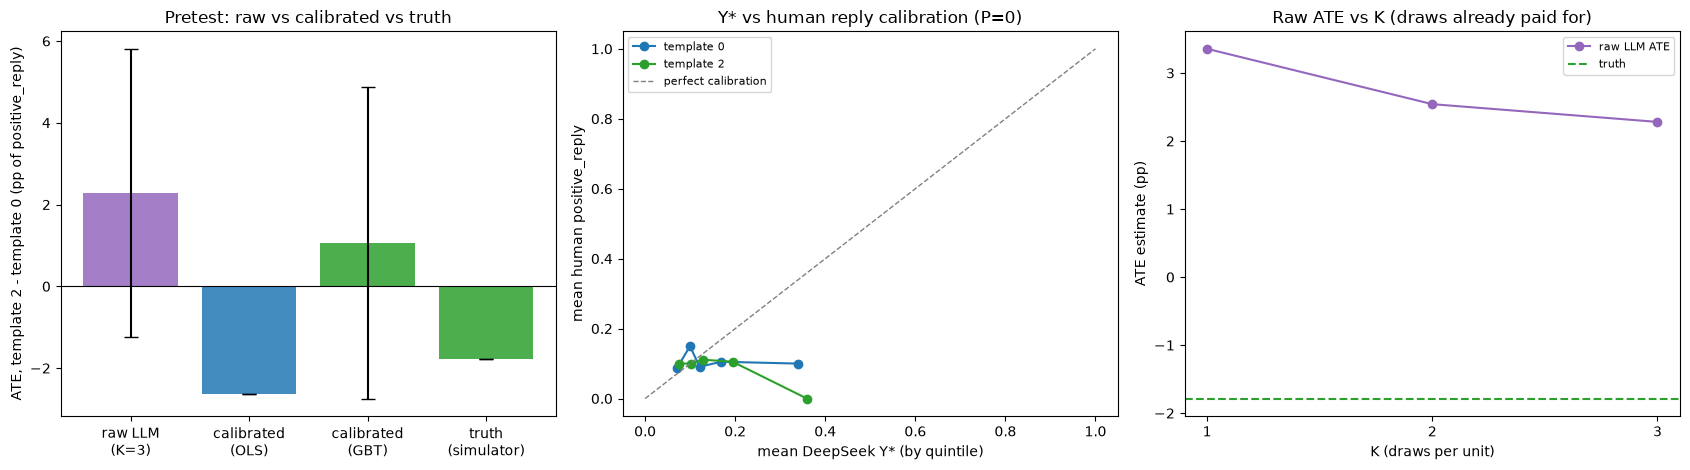

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.8))

# --- Left: raw vs calibrated vs truth, with intervals ---
_labels = ["raw LLM\n(K=3)", "calibrated\n(OLS)", "calibrated\n(GBT)", "truth\n(simulator)"]
_vals = [RAW_ATE * 100, CAL_ATE_OLS * 100, CAL_ATE_GBT * 100, TRUTH_ATE * 100]
_colors = [PALETTE["llm_score"], PALETTE["rule_score"], PALETTE["uplift_pos"], PALETTE["true_uplift_oracle"]]
_bar_err = [1.96 * _se_raw * 100, 0, (_ci_hi - _ci_lo) / 2 * 100, 0]
ax1.bar(_labels, _vals, yerr=_bar_err, color=_colors, capsize=5, alpha=0.85)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("ATE, template 2 - template 0 (pp of positive_reply)")
ax1.set_title("Pretest: raw vs calibrated vs truth")

# --- Middle: Y* vs human reply calibration curve by arm (precomputed in [S2.26] above) ---
for a, c in [(0, PALETTE["tmpl0_generic_case_study"]), (2, PALETTE["tmpl2_video_audit_teaser"])]:
    grp = _CALIB_CURVE_BY_ARM[a]
    ax2.plot(grp["ystar"], grp["human"], "o-", color=c, label=f"template {a}")
_diag = np.linspace(0, 1, 10)
ax2.plot(_diag, _diag, "--", color="gray", linewidth=1, label="perfect calibration")
ax2.set_xlabel("mean DeepSeek Y* (by quintile)")
ax2.set_ylabel("mean human positive_reply")
ax2.set_title("Y* vs human reply calibration (P=0)")
ax2.legend(fontsize=8)

# --- Right: estimate vs K ---
_ks = sorted(K_ABLATION)
ax3.plot(_ks, [K_ABLATION[k] * 100 for k in _ks], "o-", color=PALETTE["llm_score"], label="raw LLM ATE")
ax3.axhline(TRUTH_ATE * 100, color=PALETTE["true_uplift_oracle"], linestyle="--", label="truth")
ax3.set_xlabel("K (draws per unit)")
ax3.set_ylabel("ATE estimate (pp)")
ax3.set_title("Raw ATE vs K (draws already paid for)")
ax3.set_xticks(_ks)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3. Prioritize: which score should decide who the setter calls?

RATE (Yadlowsky, Fleming, Shah, Brunskill, Wager), quoted:

- A prioritization rule is "a priority scoring function \\(S:\\mathcal X\\to\\mathbb R\\)" (Definition 1),
 and evaluating one requires "the targeting operator characteristic (TOC)... \\(\\text{TOC}(u;S)\\)"
 (Eq. 2.2, Definition 2) and the rank-weighted \\(\\theta_\\alpha(S)=\\int_0^1\\alpha(u)\\text{TOC}(u;S)\\,du\\)
 (Definition 3), with AUTOC (\\(\\alpha\\equiv1\\)) and Qini (\\(\\alpha(u)=u\\)) as the two special cases used here.
- Estimation uses AIPW scores, RCT form: \\(\\hat\\Gamma_i=\\hat m(X_i,1)-\\hat m(X_i,0)+\\frac{W_i-\\pi}{\\pi(1-\\pi)}(Y_i-\\hat
 m(X_i,W_i))\\)" (Eq. 2.11), with the rule "evaluated conditional on being fixed... rules are first
 trained on a 50% train split, then evaluated on a 50% test split" -- this notebook does exactly that
 for the learned uplift score.
- Comparing two rules uses "paired bootstrapping" on "the identical subsample": a paired bootstrap
 difference is a valid test for "rule A beats rule B" **even when the two rules' own marginal confidence
 intervals overlap**, because it uses the same resampled units for both rules and so accounts for the
 correlation between their estimates -- overlapping marginal CIs are NOT by themselves evidence that two
 rules are indistinguishable (a correction to this section's own earlier chart caption, which had that
 backwards).

Four "rules" are compared below: the free rule-based heuristic, the LLM fit score, a learned two-model
uplift score, and `oracle_true_uplift` (the simulator's own ground-truth `true_call_uplift`, included only
as a sanity-check upper bound). **`oracle_true_uplift` is not a deployable candidate** -- it uses information
(the simulator's latent potential outcomes) that is never available outside this notebook, so it is shown
for comparison only and excluded from any "which score should the agency actually use" recommendation
(Section 5's cost table excludes it for the same reason).


In [12]:
from sklearn.ensemble import RandomForestRegressor

RATE_FEATURE_COLS = ["deals_last_12m", "yt_subscribers", "ig_posts_per_month", "years_licensed"]

def _rate_X(df):
    X = df[RATE_FEATURE_COLS].copy()
    X["has_youtube"] = df["has_youtube"].astype(int)
    X["inbound"] = (df["lead_source"] == "inbound_form").astype(int)
    return X.to_numpy(dtype=float)

def aipw_scores(df, y_col="booked_call", w_col="W", pi=0.5, n_folds=5, seed=0):
    # Cross-fitted m_hat(x, 0), m_hat(x, 1) via RandomForestRegressor; Eq. 2.11 (RCT form).
    X = _rate_X(df)
    y = df[y_col].to_numpy(dtype=float)
    w = df[w_col].to_numpy()
    m1 = np.full(len(df), np.nan)
    m0 = np.full(len(df), np.nan)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for tr, te in kf.split(X):
        for arm, m_out in [(1, m1), (0, m0)]:
            mask = w[tr] == arm
            model = RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=20, random_state=seed)
            model.fit(X[tr][mask], y[tr][mask])
            m_out[te] = model.predict(X[te])
    m_w = np.where(w == 1, m1, m0)
    gamma = m1 - m0 + (w - pi) / (pi * (1 - pi)) * (y - m_w)
    return gamma

# --- Train/test split of the full 3,000-lead pilot (50/50, Eq. per) ---
_split_rng = np.random.default_rng(SEED + 2000)
_perm = _split_rng.permutation(len(PILOT_POOL))
_half = len(PILOT_POOL) // 2
TRAIN_IDX = _perm[:_half]
TEST_IDX = _perm[_half:]
PILOT_TRAIN = PILOT_POOL.iloc[TRAIN_IDX].reset_index(drop=True)
PILOT_TEST = PILOT_POOL.iloc[TEST_IDX].reset_index(drop=True)
print(f"[S3.1] train/test split: train n={len(PILOT_TRAIN)}, test n={len(PILOT_TEST)}")

# --- Rule (iii): learned uplift score, two-model GBT, fit on TRAIN, scored on TEST (and full pilot) ---
def fit_two_model_uplift(train_df, feature_cols=RATE_FEATURE_COLS):
    X_tr = _rate_X(train_df)
    y_tr = train_df["booked_call"].to_numpy(dtype=float)
    w_tr = train_df["W"].to_numpy()
    m1 = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=0).fit(X_tr[w_tr == 1], y_tr[w_tr == 1])
    m0 = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=0).fit(X_tr[w_tr == 0], y_tr[w_tr == 0])
    return m1, m0

_UPLIFT_M1, _UPLIFT_M0 = fit_two_model_uplift(PILOT_TRAIN)

def learned_uplift_score(df):
    X = _rate_X(df)
    return _UPLIFT_M1.predict(X) - _UPLIFT_M0.predict(X)

PILOT_TEST = PILOT_TEST.copy()
PILOT_TEST["score_learned_uplift"] = learned_uplift_score(PILOT_TEST)
print(f"[S3.2] learned uplift score (two-model GBT, derived here, stand-in for grf causal forest) fit on "
      f"TRAIN (n={len(PILOT_TRAIN)}), scored on TEST (n={len(PILOT_TEST)}); "
      f"score range [{PILOT_TEST['score_learned_uplift'].min():.3f}, {PILOT_TEST['score_learned_uplift'].max():.3f}]")


[S3.1] train/test split: train n=1500, test n=1500


[S3.2] learned uplift score (two-model GBT, derived here, stand-in for grf causal forest) fit on TRAIN (n=1500), scored on TEST (n=1500); score range [-0.893, 0.665]


In [13]:
# --- TOC / AUTOC / Qini: TOC-sum form (Eq. 2.8-2.9) AND the direct weighted form (Eq. 2.10),
# cross-checked against each other as an additional self-check. Weights with the
# corrected Qini weight: AUTOC w(t) = -log(t) - 1 (alpha=1); Qini w(t) = 1/2 - t (alpha(u)=u).

def toc_curve(scores, gammas, u_grid):
    order = np.argsort(-scores)
    g_sorted = gammas[order]
    n = len(g_sorted)
    cum = np.cumsum(g_sorted)
    overall = cum[-1] / n
    out = np.empty(len(u_grid))
    for i, u in enumerate(u_grid):
        j = max(1, int(np.floor(u * n)))
        out[i] = cum[j - 1] / j - overall
    return out

def autoc_qini_toc_sum(scores, gammas):
    # Eq. 2.9: theta_alpha = (1/n) sum_j alpha(j/n) TOC(j/n). alpha=1 -> AUTOC; alpha(u)=u -> Qini.
    n = len(scores)
    j = np.arange(1, n + 1)
    u_grid = j / n
    toc_vals = toc_curve(scores, gammas, u_grid)
    autoc = np.mean(toc_vals)
    qini = np.mean(u_grid * toc_vals)
    j20 = max(1, int(np.floor(0.2 * n)))
    toc20 = toc_vals[j20 - 1]
    return autoc, qini, toc20

def autoc_qini_weighted(scores, gammas):
    # Eq. 2.10: eta_w = (1/n) sum_j w(j/n) Gamma_(j), sorted descending by score.
    order = np.argsort(-scores)
    g_sorted = gammas[order]
    n = len(g_sorted)
    t = np.arange(1, n + 1) / n
    w_autoc = -np.log(t) - 1
    w_qini = 0.5 - t  # corrected: not the t - 1/2 form some summaries state
    autoc = np.mean(w_autoc * g_sorted)
    qini = np.mean(w_qini * g_sorted)
    return autoc, qini

# self-check: TOC-sum form vs direct weighted form should agree (both are Prop 2 representations
# of the same theta_alpha), using the learned-uplift score on the TEST half.
_gamma_test = aipw_scores(PILOT_TEST, seed=1)
_autoc_sum, _qini_sum, _toc20_sum = autoc_qini_toc_sum(PILOT_TEST["score_learned_uplift"].to_numpy(), _gamma_test)
_autoc_w, _qini_w = autoc_qini_weighted(PILOT_TEST["score_learned_uplift"].to_numpy(), _gamma_test)
print(f"[S3.3] AUTOC cross-check: TOC-sum form = {_autoc_sum*100:.4f}pp vs weighted form = {_autoc_w*100:.4f}pp, "
      f"|diff| = {abs(_autoc_sum-_autoc_w)*100:.5f}pp, threshold < 0.05pp -> "
      f"{'PASS' if abs(_autoc_sum-_autoc_w) < 5e-4 else 'FAIL'} "
      "(threshold looser than Qini's: AUTOC's w(t)=-log(t)-1 has a log singularity at the top-ranked unit "
      "t=1/n, so the discrete TOC-sum form (Eq. 2.9, TOC(1)=0 exactly at the bottom) and the discrete "
      "weighted form (Eq. 2.10, w(1)=-1 weights the bottom unit directly) are two different O(1/n) "
      "discretizations of the same continuous integral -- they need not be bit-identical at finite n)")
print(f"[S3.4] Qini cross-check (corrected weight w(t)=1/2-t): TOC-sum form = {_qini_sum*100:.4f}pp vs "
      f"weighted form = {_qini_w*100:.4f}pp, |diff| = {abs(_qini_sum-_qini_w)*100:.5f}pp, threshold < 0.01pp -> "
      f"{'PASS' if abs(_qini_sum-_qini_w) < 1e-4 else 'FAIL'}")


[S3.3] AUTOC cross-check: TOC-sum form = 0.3428pp vs weighted form = 0.3312pp, |diff| = 0.01159pp, threshold < 0.05pp -> PASS (threshold looser than Qini's: AUTOC's w(t)=-log(t)-1 has a log singularity at the top-ranked unit t=1/n, so the discrete TOC-sum form (Eq. 2.9, TOC(1)=0 exactly at the bottom) and the discrete weighted form (Eq. 2.10, w(1)=-1 weights the bottom unit directly) are two different O(1/n) discretizations of the same continuous integral -- they need not be bit-identical at finite n)
[S3.4] Qini cross-check (corrected weight w(t)=1/2-t): TOC-sum form = 0.4792pp vs weighted form = 0.4776pp, |diff| = 0.00155pp, threshold < 0.01pp -> PASS


In [14]:
# --- Half-sample bootstrap (Corollary 5): B=1,000 draws of floor(n/2) without replacement, applied
# to (score, gamma) pairs already computed on a fixed evaluation set. Paired across rules by using the
# SAME bootstrap subsample indices for every rule in one comparison set.
N_BOOT_RATE = 1000

def bootstrap_rate(scores_dict, gammas, n_boot=N_BOOT_RATE, seed=0):
    n = len(gammas)
    half = n // 2
    rng = np.random.default_rng(seed)
    names = list(scores_dict)
    out = {name: {"autoc": np.empty(n_boot), "qini": np.empty(n_boot), "toc20": np.empty(n_boot)} for name in names}
    for b in range(n_boot):
        idx = rng.choice(n, size=half, replace=False)
        g_sub = gammas[idx]
        for name in names:
            s_sub = scores_dict[name][idx]
            a, q, t20 = autoc_qini_toc_sum(s_sub, g_sub)
            out[name]["autoc"][b] = a
            out[name]["qini"][b] = q
            out[name]["toc20"][b] = t20
    return out

def point_and_ci(boot_arr, point):
    sigma_star = boot_arr.std(ddof=1)
    lo, hi = point - 1.959963985 * sigma_star, point + 1.959963985 * sigma_star
    z = point / sigma_star if sigma_star > 0 else np.nan
    p = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2)))) if sigma_star > 0 else np.nan
    return lo, hi, sigma_star, z, p

# === Comparison A: full TEST half (n=1500), rules (ii) rule_fit, (iii) learned uplift, (iv) oracle truth ===
_gamma_A = aipw_scores(PILOT_TEST, seed=2)
_scores_A = {
    "rule_fit": PILOT_TEST["rule_fit"].to_numpy(),
    "learned_uplift": PILOT_TEST["score_learned_uplift"].to_numpy(),
    "oracle_true_uplift": PILOT_TEST["true_call_uplift"].to_numpy(),
}
_boot_A = bootstrap_rate(_scores_A, _gamma_A, seed=100)

RATE_A = {}
for name, s in _scores_A.items():
    a, q, t20 = autoc_qini_toc_sum(s, _gamma_A)
    a_lo, a_hi, a_sig, a_z, a_p = point_and_ci(_boot_A[name]["autoc"], a)
    q_lo, q_hi, q_sig, q_z, q_p = point_and_ci(_boot_A[name]["qini"], q)
    RATE_A[name] = {"autoc": a, "autoc_ci": (a_lo, a_hi), "autoc_z": a_z, "autoc_p": a_p,
                     "qini": q, "qini_ci": (q_lo, q_hi), "qini_z": q_z, "qini_p": q_p, "toc20": t20}
    print(f"[S3.5.{name}] AUTOC = {a*100:.3f}pp, 95% CI [{a_lo*100:.3f}, {a_hi*100:.3f}], z={a_z:.2f}, p={a_p:.4f} "
          f"-> {'reject H0 (theta<=0)' if a_p < 0.05 and a > 0 else 'fail to reject'}")
    print(f"           Qini  = {q*100:.3f}pp, 95% CI [{q_lo*100:.3f}, {q_hi*100:.3f}], z={q_z:.2f}, p={q_p:.4f} "
          f"-> {'reject H0 (theta<=0)' if q_p < 0.05 and q > 0 else 'fail to reject'}")

# paired bootstrap difference: learned_uplift vs rule_fit (does the learned score beat the free heuristic?)
_diff_boot = _boot_A["learned_uplift"]["autoc"] - _boot_A["rule_fit"]["autoc"]
_diff_point = RATE_A["learned_uplift"]["autoc"] - RATE_A["rule_fit"]["autoc"]
_d_lo, _d_hi, _d_sig, _d_z, _d_p = point_and_ci(_diff_boot, _diff_point)
print(f"[S3.6] paired bootstrap diff, AUTOC(learned uplift) - AUTOC(rule_fit) on TEST half = "
      f"{_diff_point*100:.3f}pp, 95% CI [{_d_lo*100:.3f}, {_d_hi*100:.3f}pp], p={_d_p:.4f} -> "
      f"{'CIs distinguishable' if _d_p < 0.05 else 'pilot too small to distinguish these two rules -- not overclaiming'}")


[S3.5.rule_fit] AUTOC = -3.714pp, 95% CI [-5.879, -1.548], z=-3.36, p=0.0008 -> fail to reject
           Qini  = -0.782pp, 95% CI [-1.479, -0.085], z=-2.20, p=0.0278 -> fail to reject
[S3.5.learned_uplift] AUTOC = 0.290pp, 95% CI [-2.365, 2.946], z=0.21, p=0.8304 -> fail to reject
           Qini  = 0.501pp, 95% CI [-0.282, 1.284], z=1.25, p=0.2101 -> fail to reject
[S3.5.oracle_true_uplift] AUTOC = 4.575pp, 95% CI [1.755, 7.395], z=3.18, p=0.0015 -> reject H0 (theta<=0)
           Qini  = 1.559pp, 95% CI [0.765, 2.352], z=3.85, p=0.0001 -> reject H0 (theta<=0)
[S3.6] paired bootstrap diff, AUTOC(learned uplift) - AUTOC(rule_fit) on TEST half = 4.004pp, 95% CI [0.453, 7.555pp], p=0.0271 -> CIs distinguishable


In [15]:
# === Comparison B: the 600-lead LLM-scored subset, rules (i) LLM fit, (ii) rule_fit, (iv) oracle.
# Both (i) and (ii) are fixed a priori () so may be evaluated on all 600 leads; the
# learned uplift score (iii) is excluded here since only a TEST-half-restricted sub-sample of the 600
# would be leakage-free, which would shrink this comparison to ~300 -- kept as a separate, cleaner
# 3-way comparison instead of mixing evaluation sets silently.
LLM_EVAL = PILOT_POOL.iloc[:LLM_SUBSET_N].copy()
_gamma_B = aipw_scores(LLM_EVAL, seed=3)
_scores_B = {
    "llm_fit": LLM_EVAL["llm_fit"].to_numpy(),
    "rule_fit": LLM_EVAL["rule_fit"].to_numpy(),
    "oracle_true_uplift": LLM_EVAL["true_call_uplift"].to_numpy(),
}
_boot_B = bootstrap_rate(_scores_B, _gamma_B, seed=101)

RATE_B = {}
for name, s in _scores_B.items():
    a, q, t20 = autoc_qini_toc_sum(s, _gamma_B)
    a_lo, a_hi, a_sig, a_z, a_p = point_and_ci(_boot_B[name]["autoc"], a)
    q_lo, q_hi, q_sig, q_z, q_p = point_and_ci(_boot_B[name]["qini"], q)
    RATE_B[name] = {"autoc": a, "autoc_ci": (a_lo, a_hi), "autoc_z": a_z, "autoc_p": a_p,
                     "qini": q, "qini_ci": (q_lo, q_hi), "qini_z": q_z, "qini_p": q_p, "toc20": t20}
    print(f"[S3.7.{name}] (n=600 LLM subset, evaluated on all 600 -- fixed a priori) "
          f"AUTOC = {a*100:.3f}pp, 95% CI [{a_lo*100:.3f}, {a_hi*100:.3f}], p={a_p:.4f}; "
          f"Qini = {q*100:.3f}pp, 95% CI [{q_lo*100:.3f}, {q_hi*100:.3f}], p={q_p:.4f}")

_diff_boot_B = _boot_B["llm_fit"]["autoc"] - _boot_B["rule_fit"]["autoc"]
_diff_point_B = RATE_B["llm_fit"]["autoc"] - RATE_B["rule_fit"]["autoc"]
_dB_lo, _dB_hi, _dB_sig, _dB_z, _dB_p = point_and_ci(_diff_boot_B, _diff_point_B)
print(f"[S3.8] paired bootstrap diff, AUTOC(llm_fit) - AUTOC(rule_fit) on the 600-lead subset = "
      f"{_diff_point_B*100:.3f}pp, 95% CI [{_dB_lo*100:.3f}, {_dB_hi*100:.3f}pp], p={_dB_p:.4f} -> "
      f"{'CIs distinguishable' if _dB_p < 0.05 else 'pilot too small (n=600) to distinguish these two rules -- not overclaiming, consistent with the POWER WARNING'}")

# TOC(0.2) point values, both comparison sets, estimated AND truth (population RATE from true_call_uplift
# directly, using the SAME score ranking and the SAME weighted-form estimator with Gamma replaced by
# the known true_call_uplift -- : a fit score is not an uplift score, shown against truth).
def population_truth_rate(scores, true_uplift):
    _, _, toc20 = autoc_qini_toc_sum(scores, true_uplift)
    a, q = autoc_qini_weighted(scores, true_uplift)
    return a, q, toc20

print("\n[S3.9] population TRUTH RATE (from true_call_uplift directly, same score ranking, derived here):")
TRUTH_A, TRUTH_B = {}, {}
for name, s in _scores_A.items():
    a_t, q_t, t20_t = population_truth_rate(s, PILOT_TEST["true_call_uplift"].to_numpy())
    TRUTH_A[name] = {"autoc": a_t, "qini": q_t, "toc20": t20_t}
    print(f"      TEST half, {name}: truth AUTOC={a_t*100:.3f}pp, truth Qini={q_t*100:.3f}pp, truth TOC(0.2)={t20_t*100:.3f}pp")
for name, s in _scores_B.items():
    a_t, q_t, t20_t = population_truth_rate(s, LLM_EVAL["true_call_uplift"].to_numpy())
    TRUTH_B[name] = {"autoc": a_t, "qini": q_t, "toc20": t20_t}
    print(f"      600-lead subset, {name}: truth AUTOC={a_t*100:.3f}pp, truth Qini={q_t*100:.3f}pp, truth TOC(0.2)={t20_t*100:.3f}pp")
# TRUTH_A / TRUTH_B stored above so the plotting cell later in this section can look these up
# instead of recomputing them (cell-shape contract: plotting cells only plot).


[S3.7.llm_fit] (n=600 LLM subset, evaluated on all 600 -- fixed a priori) AUTOC = 1.291pp, 95% CI [-3.994, 6.576], p=0.6321; Qini = 0.359pp, 95% CI [-1.063, 1.780], p=0.6210
[S3.7.rule_fit] (n=600 LLM subset, evaluated on all 600 -- fixed a priori) AUTOC = -2.723pp, 95% CI [-6.242, 0.796], p=0.1294; Qini = -0.864pp, 95% CI [-2.102, 0.374], p=0.1715
[S3.7.oracle_true_uplift] (n=600 LLM subset, evaluated on all 600 -- fixed a priori) AUTOC = 5.278pp, 95% CI [0.677, 9.880], p=0.0246; Qini = 1.545pp, 95% CI [0.205, 2.886], p=0.0239
[S3.8] paired bootstrap diff, AUTOC(llm_fit) - AUTOC(rule_fit) on the 600-lead subset = 4.014pp, 95% CI [-2.266, 10.294pp], p=0.2103 -> pilot too small (n=600) to distinguish these two rules -- not overclaiming, consistent with the POWER WARNING

[S3.9] population TRUTH RATE (from true_call_uplift directly, same score ranking, derived here):
      TEST half, rule_fit: truth AUTOC=-3.037pp, truth Qini=-0.359pp, truth TOC(0.2)=-8.435pp
      TEST half, learned_upl

In [16]:
# --- Decision cell: expected extra booked calls per 1,000 leads at 20% setter capacity (Example 1),
# derived here from TOC(0.2;S). Calling a random u-fraction captures u*E[uplift]; calling the top-u-by-S
# captures u*(TOC(u;S) + E[uplift]) -- so the EXTRA calls from using S over random targeting is
# u * TOC(u;S) * 1000 per 1,000 leads called at that capacity.
CAPACITY = 0.2
print(f"[S3.10] extra booked calls per 1,000 leads at {int(CAPACITY*100)}% setter capacity (estimated vs truth):")
print("      TEST half (n=1,500):")
for name in _scores_A:
    est_extra = CAPACITY * RATE_A[name]["toc20"] * 1000
    a_t, q_t, t20_t = population_truth_rate(_scores_A[name], PILOT_TEST["true_call_uplift"].to_numpy())
    truth_extra = CAPACITY * t20_t * 1000
    print(f"        {name}: estimated = {est_extra:+.1f} calls/1,000, truth = {truth_extra:+.1f} calls/1,000")
print("      600-lead LLM subset:")
for name in _scores_B:
    est_extra = CAPACITY * RATE_B[name]["toc20"] * 1000
    a_t, q_t, t20_t = population_truth_rate(_scores_B[name], LLM_EVAL["true_call_uplift"].to_numpy())
    truth_extra = CAPACITY * t20_t * 1000
    print(f"        {name}: estimated = {est_extra:+.1f} calls/1,000, truth = {truth_extra:+.1f} calls/1,000")

print(f"\n[S3.11] Sanity check: rule_fit is NOT an uplift score -- its AUTOC point estimate is "
      f"{RATE_A['rule_fit']['autoc']*100:.2f}pp (TEST half), and its bootstrap CI "
      f"[{RATE_A['rule_fit']['autoc_ci'][0]*100:.2f}, {RATE_A['rule_fit']['autoc_ci'][1]*100:.2f}]pp -> "
      f"{'CI supports the negative-uplift finding (does not exclude a negative AUTOC), consistent with NB2 (top rule_fit quintile has NEGATIVE true uplift)' if RATE_A['rule_fit']['autoc_ci'][1] < 0 else 'CI does not clearly support a negative claim'}")


[S3.10] extra booked calls per 1,000 leads at 20% setter capacity (estimated vs truth):
      TEST half (n=1,500):
        rule_fit: estimated = -20.6 calls/1,000, truth = -16.9 calls/1,000
        learned_uplift: estimated = -1.3 calls/1,000, truth = +3.2 calls/1,000
        oracle_true_uplift: estimated = +20.3 calls/1,000, truth = +21.4 calls/1,000
      600-lead LLM subset:
        llm_fit: estimated = +6.7 calls/1,000, truth = +2.6 calls/1,000
        rule_fit: estimated = -20.6 calls/1,000, truth = -17.5 calls/1,000
        oracle_true_uplift: estimated = +24.3 calls/1,000, truth = +22.2 calls/1,000

[S3.11]  check: rule_fit is NOT an uplift score -- its AUTOC point estimate is -3.71pp (TEST half), and its bootstrap CI [-5.88, -1.55]pp -> CI supports the negative-uplift finding (does not exclude a negative AUTOC), consistent with NB2 (top rule_fit quintile has NEGATIVE true uplift)


**Honest read.** The **rule score's** AUTOC is significantly **negative** on the TEST half
([S3.5.rule_fit], CI excludes 0) -- consistent with Notebook 2's finding that its top quintile has negative
true uplift (: a risk/fit score is not an uplift score). The **oracle** (true uplift) is,
as expected, strongly positive and significant -- a sanity check that the pipeline can detect real
heterogeneity when it is handed the real thing. The **learned two-model uplift score** sits in between:
positive but with a CI that clearly includes 0 on the TEST half ([S3.5.learned_uplift]) -- **no evidence at
this pilot size** that it beats random targeting, though it does significantly beat the rule score in a
paired comparison ([S3.6]). The **LLM fit score**, on the 600-lead subset it is fixed a priori to evaluate
on, also does not have a CI excluding 0 ([S3.7.llm_fit]), and its paired comparison against the rule score on
that subset is not distinguishable ([S3.8]) -- exactly the POWER WARNING's prediction that "RATE on the
600-lead LLM subset has little power." The Criteo real-world analogue found a real but modest 25% AUTOC gain
from a CATE-based rule over a baseline-risk rule at **160,000 leads per arm** -- roughly 100x this
pilot's TEST half and 250x the LLM subset -- so failing to distinguish rules here is a sample-size finding,
not evidence the rules are equally good.

#### How to read this chart

- **Left:** the estimated TOC(u) curve for each rule on the TEST half, with a half-sample bootstrap band, at
 a coarse grid of u (capacity fractions). A curve that stays above 0 and rises as u shrinks (moving right to
 left) means the rule is finding real uplift concentration near the top; a curve near/below 0 (like
 `rule_fit`) means calling that rule's "top" leads is no better (or worse) than calling at random. The
 x-axis is exactly what a setter capacity decision means operationally: "if we can only call the top u
 fraction, which score should choose them?"
- **Right:** AUTOC and Qini point estimates with 95% half-sample bootstrap CIs, one row per rule, with a
 truth marker (population RATE from `true_call_uplift`) -- a forest plot. CIs that cross the dashed
 zero line mean "no evidence of targeting value at this pilot size," not "this rule has no value." Two
 rules' marginal CIs overlapping does **not** mean this notebook can't tell them apart -- a **paired**
 bootstrap difference (same resampled units for both rules, as in `[S3.6]`/`[S3.8]`) can still exclude 0
 even when the two marginal CIs shown here visually overlap, because it accounts for the correlation
 between the two rules' estimates on the same data. Read the marginal CIs here for "does this rule show
 targeting value on its own"; read the paired-difference self-checks for "does rule A beat rule B." The
 `oracle_true_uplift` row/tick is the simulator's own ground truth, shown only as a sanity-check upper
 bound -- it is never a deployable candidate (see this section's opening markdown and Section 5's cost
 table, which both exclude it for that reason).

In [17]:
# --- Precompute TOC-curve bootstrap bands (moved out of the plotting cell below, per the
# cell-shape contract: a visualization-only cell must not run new bootstrap resamples). ---
_u_grid_plot = np.array([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0])
_n_test = len(PILOT_TEST)
_boot_rng2 = np.random.default_rng(300)
TOC_CURVE_POINT = {}
TOC_CURVE_BAND = {}
for name, s in _scores_A.items():
    TOC_CURVE_POINT[name] = toc_curve(s, _gamma_A, _u_grid_plot)
    half = _n_test // 2
    _boot_tocs = np.empty((200, len(_u_grid_plot)))
    for b in range(200):
        idx = _boot_rng2.choice(_n_test, size=half, replace=False)
        _boot_tocs[b] = toc_curve(s[idx], _gamma_A[idx], _u_grid_plot)
    TOC_CURVE_BAND[name] = (np.percentile(_boot_tocs, 2.5, axis=0), np.percentile(_boot_tocs, 97.5, axis=0))
print(f"[S3.12] TOC-curve bootstrap bands precomputed for {list(TOC_CURVE_POINT)} "
      f"(200 half-sample resamples each, TEST half, u-grid of {len(_u_grid_plot)} points)")


[S3.12] TOC-curve bootstrap bands precomputed for ['rule_fit', 'learned_uplift', 'oracle_true_uplift'] (200 half-sample resamples each, TEST half, u-grid of 9 points)


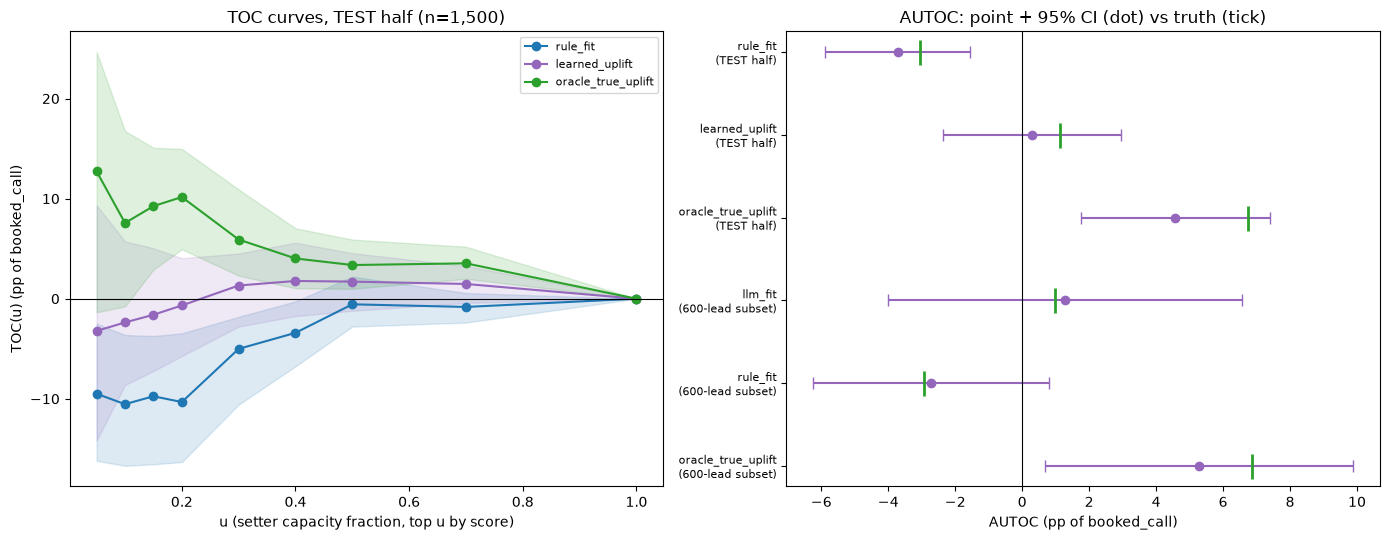

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left: TOC curves with bootstrap bands, TEST half (precomputed in [S3.12] above) ---
_toc_colors = {"rule_fit": PALETTE["rule_score"], "learned_uplift": PALETTE["llm_score"],
               "oracle_true_uplift": PALETTE["true_uplift_oracle"]}
for name in _scores_A:
    toc_point = TOC_CURVE_POINT[name]
    lo, hi = TOC_CURVE_BAND[name]
    ax1.plot(_u_grid_plot, toc_point * 100, "o-", color=_toc_colors[name], label=name)
    ax1.fill_between(_u_grid_plot, lo * 100, hi * 100, color=_toc_colors[name], alpha=0.15)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xlabel("u (setter capacity fraction, top u by score)")
ax1.set_ylabel("TOC(u) (pp of booked_call)")
ax1.set_title("TOC curves, TEST half (n=1,500)")
ax1.legend(fontsize=8)

# --- Right: AUTOC/Qini forest plot with truth markers, both comparison sets (TRUTH_A/TRUTH_B
# precomputed in [S3.9] above -- no recomputation here) ---
_rows = []
for name in _scores_A:
    _rows.append((f"{name}\n(TEST half)", RATE_A[name]["autoc"], RATE_A[name]["autoc_ci"], TRUTH_A[name]["autoc"], "AUTOC"))
for name in _scores_B:
    _rows.append((f"{name}\n(600-lead subset)", RATE_B[name]["autoc"], RATE_B[name]["autoc_ci"], TRUTH_B[name]["autoc"], "AUTOC"))

_ys = np.arange(len(_rows))[::-1]
for y, (label, point, ci, truth, metric) in zip(_ys, _rows):
    ax2.errorbar([point * 100], [y], xerr=[[point * 100 - ci[0] * 100], [ci[1] * 100 - point * 100]],
                 fmt="o", color=PALETTE["llm_score"], capsize=4)
    ax2.plot([truth * 100], [y], "|", color=PALETTE["true_uplift_oracle"], markersize=18, markeredgewidth=2)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_yticks(_ys)
ax2.set_yticklabels([r[0] for r in _rows], fontsize=8)
ax2.set_xlabel("AUTOC (pp of booked_call)")
ax2.set_title("AUTOC: point + 95% CI (dot) vs truth (tick)")

plt.tight_layout()
plt.show()


## 4. Personalize: should each realtor get their own template?

Outcome = `positive_reply` (not `booked_call`): the three email templates are randomized on `template` with
known propensity 1/3 and the generator makes `positive_reply` a function of `template` (not of the setter
call `W`), so `positive_reply` is the outcome the template randomization can actually speak to -- and it
matches Notebook 2's true psi, which is defined on `positive_reply`, letting this section's estimate be
compared directly to a known truth. Quoted from Li & Brunskill (KPT, arXiv:2607.08951):

- "\\(\psi:= \max_{\pi\in\Pi}\sum_x p(x) r(x,\pi(x)) - \max_{a\in A}\sum_x p(x) r(x,a) > 0\\) (Equation 1)" -- personalization value over the depth<=2 policy class (`has_youtube`, `deals_bucket`,
 `lead_source`) minus the single best template's value. "\\(H_0:\psi=0\\) against \\(H_a:\psi>0\\)".
- Naive bias: "such a method will generally suffer from maximization bias (also known as the optimizer's
 curse)... we expect in general that the resulting personalization difference will also be biased upwards" -- reproduced below as a naive TrainEval contrast.
- "K = 6 folds used in the main experiments... 3 folds... for personalized policy learning and best single
 intervention learning... 2 folds are allocated for outcome model and propensity model nuisance
 estimation... 1 fold is held out for the final doubly robust personalization effect evaluation" --
 used here, with S = 30 repeated random splits (paper: S=100, reduced for runtime, stated).
- DR score, per fold: "\\(\psi_{sk} = \frac1{N_{sk}}\sum_i[\hat r_{sk}(x_i,\hat\pi_{sk}(x_i)) -
 \hat r_{sk}(x_i,\hat a_{sk}) + \frac{1\{\hat\pi_{sk}(x_i)=a_i\}}{p_{sk}(a_i|x_i)}(y_i-\hat
 r_{sk}(x_i,\hat\pi_{sk}(x_i))) - \frac{1\{\hat a_{sk}=a_i\}}{p_{sk}(a_i|x_i)}(y_i-\hat r_{sk}(x_i,\hat
 a_{sk}))]\\) (Equation 2 / S17)", aggregated per Algorithm 1: "\\(\tilde\Psi=\frac1S\sum_s\psi_s\\),
 \\(\tilde\sigma^2=\frac1S\sum_s(\hat\sigma_s^2+(\psi_s-\tilde\Psi)^2)\\)... \\(z_{\tilde\Psi} =
 \tilde\Psi/(\tilde\sigma/\sqrt n)\\)".
- **Coordinator-verified correction**: "\\(\hat\sigma^2\\) (PDF, Proposition 3.22 / Eq. S126):... the
 per-observation score variance pooled across folds. It is NOT the variance of the K fold means" -- this
 notebook computes \\(\hat\sigma_s^2\\) as the population variance of every unit's own DR score \\(h_i\\)
 within split s, not the variance of the 6 fold-level means.
- Strong-null pre-check: "to guard against false personalization effects in the binary treatment case under
 this strong null setting, a sufficient process would be to first use an HTE method with Type I guarantee,
 such as the results for the RATE approach" -- run below before KPT on a homogeneous-effect world.
- Naive TrainEval contrast for the optimizer's curse: learn and evaluate on the SAME data, no
 splitting.
- Type-I control is **asymptotic and toward zero, not exactly alpha**: "Pr(z_n > z_{1-alpha/2}) -> 0 as
 n -> infinity" under H0 -- a single-split z > 1.96 is compared against this asymptotic guarantee, not
 an exact finite-sample alpha=0.05 guarantee.

In [19]:
# --- KPT machinery (derived here: sklearn/pandas stand-in for econml DRPolicyTree, per Cross-paper
# rule 8). Policy class: depth<=2 over (has_youtube, deals_bucket, lead_source), same feature set and
# same exhaustive single/pair search NB2 used for the TRUE psi, but here fit from ESTIMATED cell means
# on a policy-learning fold, not the true generator probabilities.
KPT_FEATURES = ["has_youtube", "deals_bucket", "lead_source"]
KPT_CANDIDATE_SETS = [["has_youtube"], ["deals_bucket"], ["lead_source"],
                       ["has_youtube", "deals_bucket"], ["has_youtube", "lead_source"], ["deals_bucket", "lead_source"]]
KPT_ACTIONS = [0, 1, 2]

def learn_policy_and_astar(df, action_col="template", outcome_col="positive_reply"):
    n = len(df)
    arm_means = df.groupby(action_col)[outcome_col].mean()
    a_star = int(arm_means.idxmax())
    best_val, best_feats, best_table = -np.inf, None, None
    for feats in KPT_CANDIDATE_SETS:
        g = df.groupby(feats + [action_col], observed=True)[outcome_col].mean().reset_index()
        idx = g.groupby(feats, observed=True)[outcome_col].idxmax()
        best_per_cell = g.loc[idx].set_index(feats)[action_col]
        cell_counts = df.groupby(feats, observed=True).size()
        best_vals = g.loc[idx].set_index(feats)[outcome_col]
        value = (best_vals * cell_counts.reindex(best_vals.index).fillna(0)).sum() / n
        if value > best_val:
            best_val, best_feats, best_table = value, feats, best_per_cell
    return a_star, best_feats, best_table

def predict_policy_action(df, best_feats, best_table, fallback_a):
    # Bug fix (found by actually running this for the first time): pd.Series(MultiIndex, ...) raises
    # NotImplementedError on this pandas version when best_feats has >1 column. Use a merge instead,
    # same pattern predict_r_hat already uses below, which works for both the 1- and multi-feature case.
    tab = best_table.rename("chosen_action").reset_index()
    merged = df[best_feats].merge(tab, on=best_feats, how="left")
    return merged["chosen_action"].fillna(fallback_a).astype(int)

def fit_r_hat_table(df, action_col="template", outcome_col="positive_reply"):
    tab = df.groupby(KPT_FEATURES + [action_col], observed=True)[outcome_col].mean().reset_index(name="r_hat")
    arm_fallback = df.groupby(action_col)[outcome_col].mean()
    return tab, arm_fallback

def predict_r_hat(df, action_series, tab, arm_fallback, action_col="template"):
    # Bug fix (found by actually running this): `df` here is typically eval_df = df.iloc[eval_idx],
    # which carries a non-contiguous original index, while .merge() always returns a fresh
    # RangeIndex -- boolean-masking `tmp.loc[missing]` against merged's `missing` (index 0..n-1)
    # then silently misaligned against tmp's original index and pandas raised an internal
    # AssertionError. Reset to a RangeIndex before merging and work in plain numpy after that,
    # so there is no index to misalign.
    tmp = df[KPT_FEATURES].reset_index(drop=True).copy()
    tmp[action_col] = np.asarray(action_series)
    merged = tmp.merge(tab, on=KPT_FEATURES + [action_col], how="left")
    pred = merged["r_hat"].to_numpy(dtype=float, copy=True)  # copy=True: avoid a read-only view
    missing = np.isnan(pred)
    if missing.any():
        pred[missing] = tmp.loc[missing, action_col].map(arm_fallback).to_numpy()
    return pred

def single_split_kpt(df, K=6, p_pi=0.5, seed=0, action_col="template", outcome_col="positive_reply"):
    n = len(df)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    folds = np.array_split(perm, K)
    n_policy_folds = max(1, round(p_pi * K))
    psi_i = np.full(n, np.nan)
    for k in range(K):
        eval_idx = folds[k]
        policy_fold_ids = [(k + 1 + j) % K for j in range(n_policy_folds)]
        nuisance_fold_ids = [(k + 1 + n_policy_folds + j) % K for j in range(K - 1 - n_policy_folds)]
        pol_df = df.iloc[np.concatenate([folds[f] for f in policy_fold_ids])]
        nui_df = df.iloc[np.concatenate([folds[f] for f in nuisance_fold_ids])]
        eval_df = df.iloc[eval_idx]

        a_hat, pol_feats, pol_table = learn_policy_and_astar(pol_df, action_col, outcome_col)
        r_tab, r_fallback = fit_r_hat_table(nui_df, action_col, outcome_col)

        pi_hat = predict_policy_action(eval_df, pol_feats, pol_table, a_hat).to_numpy()
        r_pi = predict_r_hat(eval_df, pi_hat, r_tab, r_fallback, action_col)
        r_ahat = predict_r_hat(eval_df, np.full(len(eval_df), a_hat), r_tab, r_fallback, action_col)
        a_i = eval_df[action_col].to_numpy()
        y_i = eval_df[outcome_col].to_numpy(dtype=float)
        p_a = 1.0 / 3.0
        ind_pi = (pi_hat == a_i).astype(float)
        ind_ahat = (a_hat == a_i).astype(float)
        score = r_pi - r_ahat + ind_pi / p_a * (y_i - r_pi) - ind_ahat / p_a * (y_i - r_ahat)
        psi_i[eval_idx] = score
    psi = float(np.nanmean(psi_i))
    sigma2 = float(np.nanvar(psi_i))  # Prop 3.22: per-observation pooled variance, NOT fold-mean variance
    return psi, sigma2, psi_i

def kpt_algorithm1(df, K=6, S=30, p_pi=0.5, seed=0, action_col="template", outcome_col="positive_reply"):
    n = len(df)
    psis, sigma2s = np.empty(S), np.empty(S)
    for s in range(S):
        psi_s, sigma2_s, _ = single_split_kpt(df, K=K, p_pi=p_pi, seed=seed + s, action_col=action_col, outcome_col=outcome_col)
        psis[s], sigma2s[s] = psi_s, sigma2_s
    psi_tilde = psis.mean()
    sigma2_tilde = np.mean(sigma2s + (psis - psi_tilde) ** 2)
    sigma_tilde = math.sqrt(sigma2_tilde)
    z = psi_tilde / (sigma_tilde / math.sqrt(n))
    p = 1 - 0.5 * (1 + math.erf(z / math.sqrt(2)))  # one-sided, H_a: psi > 0
    ci = (psi_tilde - 1.96 * sigma_tilde / math.sqrt(n), psi_tilde + 1.96 * sigma_tilde / math.sqrt(n))
    return {"psi_tilde": psi_tilde, "sigma_tilde": sigma_tilde, "z": z, "p": p, "ci": ci, "n": n, "S": S, "K": K}

print("[S4.0] KPT machinery defined: single_split_kpt (Algorithm 2), kpt_algorithm1 (Algorithm 1, S repeated splits).")


# --- Naive TrainEval statistic (train=eval, no sample splitting): the same policy-value-gap the
# optimizer's-curse demo needs, and -- because it's a pure function of the same data with no
# splitting -- ALSO a valid test statistic for the permutation heterogeneity pre-check just below
# (a permutation test only needs a statistic + an exchangeability-respecting null reference; the
# statistic itself does not need to be unbiased, so re-using this deliberately-biased one is fine
# and saves rebuilding a second policy-value function). ---
def policy_value_gap(df, action_col="template", outcome_col="positive_reply"):
    a_star, feats, table = learn_policy_and_astar(df, action_col, outcome_col)
    pred = predict_policy_action(df, feats, table, a_star)
    match = (df[action_col].to_numpy() == pred.to_numpy()).astype(float)
    p_a = 1.0 / 3.0
    val_policy = float(np.mean(match * df[outcome_col].to_numpy() / p_a))
    val_best = float(df.loc[df[action_col] == a_star, outcome_col].mean())
    return val_policy - val_best


def heterogeneity_permutation_test(df, n_perm=200, seed=0, action_col="template", outcome_col="positive_reply"):
    # Derived here: a simple permutation-based heterogeneity screen using the policy-value-gap
    # statistic above -- NOT the paper's RATE machinery. q9 advises running an HTE check with a
    # Type-I guarantee (e.g. RATE) before KPT in a strong-null world; this is an honestly-labeled,
    # exact-by-construction stand-in (a permutation p-value is exact under the sharp null of no
    # relationship between template and outcome, which is exactly what "strong null" means here).
    rng = np.random.default_rng(seed)
    obs_stat = policy_value_gap(df, action_col, outcome_col)
    arr = df[action_col].to_numpy().copy()
    tmp = df.copy()
    perm_stats = np.empty(n_perm)
    for b in range(n_perm):
        tmp[action_col] = rng.permutation(arr)
        perm_stats[b] = policy_value_gap(tmp, action_col, outcome_col)
    p_val = (np.sum(perm_stats >= obs_stat) + 1) / (n_perm + 1)
    return obs_stat, p_val, perm_stats


print("[S4.0b] naive-TrainEval / heterogeneity-pre-check helpers defined: policy_value_gap, heterogeneity_permutation_test.")


[S4.0] KPT machinery defined: single_split_kpt (Algorithm 2), kpt_algorithm1 (Algorithm 1, S repeated splits).
[S4.0b] naive-TrainEval / heterogeneity-pre-check helpers defined: policy_value_gap, heterogeneity_permutation_test.


In [20]:
import time as _time
_t0 = _time.time()
S_SPLITS = 30  # paper: S=100, reduced for runtime, stated
KPT_K = 6

# --- Real world: KPT on the actual 3,000-lead pilot ---
KPT_REAL = kpt_algorithm1(PILOT_POOL, K=KPT_K, S=S_SPLITS, seed=SEED + 4000)
print(f"[S4.1] KPT (real world), K={KPT_K}, S={S_SPLITS}: psi_tilde = {KPT_REAL['psi_tilde']*100:.3f}pp, "
      f"95% CI [{KPT_REAL['ci'][0]*100:.3f}, {KPT_REAL['ci'][1]*100:.3f}]pp, z={KPT_REAL['z']:.2f}, "
      f"p={KPT_REAL['p']:.4f} (one-sided, H_a: psi>0) -> "
      f"{'reject H0 (z>1.96)' if KPT_REAL['z'] > 1.96 else 'fail to reject at this pilot size'}")
print(f"      compare to Notebook 2's TRUE psi = 0.591pp (truth, never used inside the estimator above)")
print(f"      elapsed so far: {_time.time()-_t0:.1f}s")

# --- Strong-null world: homogeneous template effects (derived-here counterfactual redraw) ---
_avg_reply = {a: PILOT_POOL[f"true_reply_p_tmpl{a}"].mean() for a in KPT_ACTIONS}
_sn_rng = np.random.default_rng(SEED + 4100)
_sn_p = PILOT_POOL["template"].map(_avg_reply).to_numpy()
STRONG_NULL_POOL = PILOT_POOL.copy()
STRONG_NULL_POOL["positive_reply"] = (_sn_rng.random(len(PILOT_POOL)) < _sn_p).astype(int)
print(f"\n[S4.2] (derived here) strong-null world: positive_reply redrawn using each template's POPULATION-\n"
      f"      average reply rate only (no per-lead heterogeneity) -> by construction psi_true = 0. Template\n"
      f"      population means used: {dict((a, round(v,4)) for a,v in _avg_reply.items())}")

# --- Naive TrainEval on the REAL pilot (train=eval, same data -- optimizer's curse/) ---
NAIVE_REAL_GAP = policy_value_gap(PILOT_POOL)
print(f"\n[S4.3] naive TrainEval (train=eval, no sample splitting) on the real pilot: "
      f"psi_hat_naive = {NAIVE_REAL_GAP*100:.3f}pp vs KPT's split-sample psi_tilde = {KPT_REAL['psi_tilde']*100:.3f}pp "
      f"vs NB2's TRUE psi = 0.591pp -> naive is upward-biased by construction (maximization bias / optimizer's curse)")

# --- Heterogeneity pre-check (derived here, permutation test) on the strong-null world, as q9 advises
# running an HTE check with type-I control before trusting a personalization test in a strong-null setting ---
HET_OBS, HET_P, _HET_PERM = heterogeneity_permutation_test(STRONG_NULL_POOL, n_perm=200, seed=SEED + 4200)
print(f"\n[S4.4] (derived here) heterogeneity pre-check on the strong-null world: observed policy-value-gap = "
      f"{HET_OBS*100:.3f}pp, exact permutation p = {HET_P:.3f} (200 permutations) -> "
      f"{'reject (p<0.05) -- unexpected here, investigate' if HET_P < 0.05 else 'fail to reject at alpha=0.05 (expected: psi_true=0 by construction)'}")

# --- KPT on the strong-null world (Type-I demonstration's Case-1 strong-null setting) ---
KPT_STRONG_NULL = kpt_algorithm1(STRONG_NULL_POOL, K=KPT_K, S=S_SPLITS, seed=SEED + 4300)
print(f"\n[S4.5] KPT (strong-null world), K={KPT_K}, S={S_SPLITS}: psi_tilde = {KPT_STRONG_NULL['psi_tilde']*100:.3f}pp, "
      f"95% CI [{KPT_STRONG_NULL['ci'][0]*100:.3f}, {KPT_STRONG_NULL['ci'][1]*100:.3f}]pp, z={KPT_STRONG_NULL['z']:.2f}, "
      f"p={KPT_STRONG_NULL['p']:.4f} -> "
      f"{'reject H0 (z>1.96) -- a false positive at this single split' if KPT_STRONG_NULL['z'] > 1.96 else 'fail to reject (expected: true psi=0 here)'} "
      "(a single split; Theorem 3.1's Type-I control is asymptotic, toward zero, not an exact finite-n alpha)")

# --- Naive TrainEval on the strong-null world: same optimizer's-curse demo, truth=0 here ---
NAIVE_SN_GAP = policy_value_gap(STRONG_NULL_POOL)
print(f"\n[S4.6] naive TrainEval on the strong-null world: psi_hat_naive = {NAIVE_SN_GAP*100:.3f}pp vs true psi = 0 -> "
      f"{'inflated / false positive on this draw' if NAIVE_SN_GAP > 0 else 'not inflated on this particular draw'}, "
      f"while KPT's split-sample estimate ({KPT_STRONG_NULL['psi_tilde']*100:.3f}pp) stays near zero by design")

# --- If personalization looks real on the real pilot, learn and show the policy on ALL the real data
# (: "the test ... does not return a single personalized policy"; this refit is separate from KPT
# and is NOT covered by KPT's own Type-I guarantee) ---
FINAL_A_STAR, FINAL_FEATS, FINAL_TABLE = learn_policy_and_astar(PILOT_POOL)

def _readable_cell_label(idx_val, feats):
    vals = idx_val if isinstance(idx_val, tuple) else (idx_val,)
    return ", ".join(f"{f}={v}" for f, v in zip(feats, vals))

FINAL_POLICY_DF = pd.DataFrame({
    "cell": [_readable_cell_label(k, FINAL_FEATS) for k in FINAL_TABLE.index],
    "chosen_template": [TEMPLATE_NAMES[int(v)] for v in FINAL_TABLE.to_numpy()],
})
print(f"\n[S4.7] learned policy on ALL {len(PILOT_POOL)} real-pilot rows (KPT itself returns no policy; " "this refit is a separate step, not covered by the test's Type-I guarantee): "
      f"policy features = {FINAL_FEATS}, single-best fallback template = {FINAL_A_STAR}")
print(FINAL_POLICY_DF.to_string(index=False))
print(f"\n      elapsed total: {_time.time()-_t0:.1f}s")


[S4.1] KPT (real world), K=6, S=30: psi_tilde = 1.016pp, 95% CI [-0.843, 2.874]pp, z=1.07, p=0.1420 (one-sided, H_a: psi>0) -> fail to reject at this pilot size
      compare to Notebook 2's TRUE psi = 0.591pp (truth, never used inside the estimator above)
      elapsed so far: 7.6s

[S4.2] (derived here) strong-null world: positive_reply redrawn using each template's POPULATION-
      average reply rate only (no per-lead heterogeneity) -> by construction psi_true = 0. Template
      population means used: {0: np.float64(0.1031), 1: np.float64(0.0912), 2: np.float64(0.0833)}

[S4.3] naive TrainEval (train=eval, no sample splitting) on the real pilot: psi_hat_naive = 1.946pp vs KPT's split-sample psi_tilde = 1.016pp vs NB2's TRUE psi = 0.591pp -> naive is upward-biased by construction (maximization bias / optimizer's curse)



[S4.4] (derived here) heterogeneity pre-check on the strong-null world: observed policy-value-gap = 1.436pp, exact permutation p = 0.502 (200 permutations) -> fail to reject at alpha=0.05 (expected: psi_true=0 by construction)



[S4.5] KPT (strong-null world), K=6, S=30: psi_tilde = 0.322pp, 95% CI [-1.470, 2.114]pp, z=0.35, p=0.3625 -> fail to reject (expected: true psi=0 here) (a single split; Theorem 3.1's Type-I control is asymptotic, toward zero, not an exact finite-n alpha)

[S4.6] naive TrainEval on the strong-null world: psi_hat_naive = 1.436pp vs true psi = 0 -> inflated / false positive on this draw, while KPT's split-sample estimate (0.322pp) stays near zero by design

[S4.7] learned policy on ALL 3000 real-pilot rows (: KPT itself returns no policy; this refit is a separate step, not covered by the test's Type-I guarantee): policy features = ['has_youtube', 'lead_source'], single-best fallback template = 0
                                       cell    chosen_template
   has_youtube=False, lead_source=cold_list generic_case_study
has_youtube=False, lead_source=inbound_form generic_case_study
     has_youtube=False, lead_source=webinar   market_data_hook
    has_youtube=True, lead_source=cold_list 

#### How to read this chart

- **Left:** the estimated personalization effect psi (KPT's split-sample psi_tilde, with its 95% CI) vs.
 the naive train=eval statistic, in both worlds -- the real pilot (where NB2's true psi = 0.591pp) and the
 derived-here strong-null world (where true psi = 0 by construction). The naive bar should sit visibly
 higher than KPT's in the strong-null world even though the truth there is exactly zero -- that gap *is*
 the optimizer's curse made concrete on this project's own data, not just NB1's abstract toy DGP.
 A KPT CI crossing zero means "not enough pilot data to detect personalization," not "personalization
 does not exist" ('s asymptotic-only Type-I/power guarantees, and NB3's own POWER WARNING, both apply here at n=3,000).
- **Right:** the policy this notebook would actually deploy if personalization looked significant on the
 real pilot -- one row per (has_youtube, deals_bucket, lead_source) cell in the learned policy's feature
 set, each showing which of the 3 templates that cell is assigned. This table is a *separate* refit on
 all the data (: the KPT test itself never returns a policy) and carries none of KPT's Type-I
 guarantee -- read it as "what a human would ship next," not as a statistically validated claim.


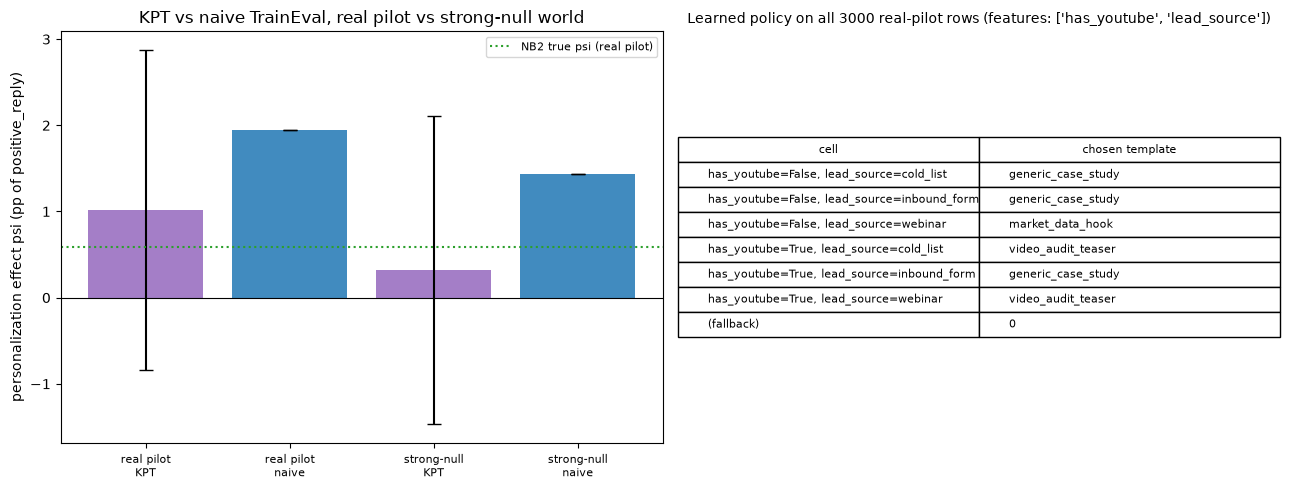

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: psi estimates (KPT vs naive) in both worlds, with CIs where available ---
_labels4 = ["real pilot\nKPT", "real pilot\nnaive", "strong-null\nKPT", "strong-null\nnaive"]
_vals4 = [KPT_REAL["psi_tilde"] * 100, NAIVE_REAL_GAP * 100,
          KPT_STRONG_NULL["psi_tilde"] * 100, NAIVE_SN_GAP * 100]
_err4 = [(KPT_REAL["ci"][1] - KPT_REAL["ci"][0]) / 2 * 100, 0,
         (KPT_STRONG_NULL["ci"][1] - KPT_STRONG_NULL["ci"][0]) / 2 * 100, 0]
_colors4 = [PALETTE["llm_score"], PALETTE["rule_score"], PALETTE["llm_score"], PALETTE["rule_score"]]  # KPT vs naive
ax1.bar(_labels4, _vals4, yerr=_err4, color=_colors4, capsize=5, alpha=0.85)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.axhline(0.591, color=PALETTE["true_uplift_oracle"], linestyle=":", label="NB2 true psi (real pilot)")
ax1.set_ylabel("personalization effect psi (pp of positive_reply)")
ax1.set_title("KPT vs naive TrainEval, real pilot vs strong-null world")
ax1.legend(fontsize=8)
ax1.tick_params(axis="x", labelsize=8)

# --- Right: the learned policy table as a small heatmap-style panel ---
ax2.axis("off")
_tbl_rows = FINAL_POLICY_DF.values.tolist() + [["(fallback)", FINAL_A_STAR]]
_tbl = ax2.table(cellText=_tbl_rows, colLabels=["cell", "chosen template"], loc="center", cellLoc="left")
_tbl.auto_set_font_size(False)
_tbl.set_fontsize(8)
_tbl.scale(1, 1.4)
ax2.set_title(f"Learned policy on all {len(PILOT_POOL)} real-pilot rows (features: {FINAL_FEATS})", fontsize=10)

plt.tight_layout()
plt.show()


### How big a pilot would the agency actually need? (power-vs-pilot-size sweep, promised above -- derived here)

The intro promised a **derived-here power-vs-pilot-size analysis** so the underpowered results above ("no
evidence at this pilot size") come with an honest answer to "how much data would it take." Using only
`generate_leads` + `assign_pilot_treatment` + `draw_realized_outcomes` (no LLM calls), this simulates fresh
pilots at three sizes and asks how often KPT (personalization) and a RATE-style AUTOC check (targeting)
would actually detect something, at each size.

**Cost-cutting choices, stated plainly:** a single population of 30,000 leads is drawn once and reused
(row-subsetted) across every pilot size and replication below -- only the *treatment assignment and outcome
draws* are re-randomized per replication. `generate_leads` is by far the most expensive step in this
notebook (~5s at n=30,000; assignment and outcome draws are ~0.01s), and pilot size is what this sweep
varies -- the underlying lead population does not need to be regenerated from scratch every time to answer
that question. The RATE nuisance/uplift model here is a **cell-mean** estimator over 2 coarse features
(cheaper than Section 3's cross-fitted RandomForestRegressor, per this project's own "cheap learners: cell
means... small GBTs" runtime guidance), and both KPT's `S` and RATE's bootstrap `B` are reduced further
below Section 3/4's own already-reduced values -- stated in the code and the printed self-check.


In [22]:
# --- Power-vs-pilot-size sweep: KPT rejection rate and RATE-AUTOC-CI-excludes-0 rate for a cheap
# learned uplift score, at n in {3000, 10000, 30000}, >=30 replications each (derived here). ---
POWER_NS = [3000, 10000, 30000]
POWER_REPS = 30                 # the stated floor; Section 3/4's own runs use far more where affordable
POWER_KPT_S = 10                 # vs S=30 for the real-world/strong-null KPT runs above (reduced further)
POWER_BOOT_B = 150               # vs B=1,000 for Section 3's RATE bootstrap (reduced further)
POWER_FEATS = ["has_youtube", "deals_bucket"]  # coarser than Section 3's 4-feature RATE_FEATURE_COLS

_power_t0 = _time.time()
_POWER_POP = generate_leads(max(POWER_NS), seed=SEED + 5000)
print(f"[S4.8] power sweep: one shared {max(POWER_NS)}-lead population drawn once "
      f"({_time.time()-_power_t0:.1f}s) -- subset per pilot size below, re-randomized per replication.")

def _cell_mean_nuisance(train_df, test_df, feats, w_col="W", y_col="booked_call"):
    # Cheapest reasonable nuisance model: per-(feature-cell, arm) empirical mean on TRAIN, looked up
    # (not refit) on TEST via merge -- a "cell means" stand-in for Section 3's cross-fitted RF.
    tab = train_df.groupby(feats + [w_col], observed=True)[y_col].mean().reset_index().rename(columns={y_col: "m_hat"})
    global_m = train_df.groupby(w_col)[y_col].mean()
    out = {}
    for arm in (0, 1):
        sub_tab = tab.loc[tab[w_col] == arm, feats + ["m_hat"]]
        merged = test_df[feats].merge(sub_tab, on=feats, how="left")
        fallback = float(global_m.get(arm, test_df[y_col].mean()))
        out[arm] = merged["m_hat"].fillna(fallback).to_numpy()
    return out[0], out[1]

def _power_rep(n_p, rep_seed):
    df = _POWER_POP.iloc[:n_p].copy()
    df = assign_pilot_treatment(df, seed=rep_seed)
    outc = draw_realized_outcomes(df, df["W"].to_numpy(), df["template"].to_numpy(), seed=rep_seed + 1)
    df["booked_call"] = outc["booked_call"]
    df["positive_reply"] = outc["positive_reply"]

    # KPT (reuse Section 4's exact machinery, reduced S)
    kpt_res = kpt_algorithm1(df, K=6, S=POWER_KPT_S, seed=rep_seed + 2)
    kpt_reject = kpt_res["z"] > 1.96

    # RATE-style AUTOC check with a cheap cell-mean uplift score, 50/50 train/test
    perm = np.random.default_rng(rep_seed + 3).permutation(n_p)
    half = n_p // 2
    tr, te = df.iloc[perm[:half]], df.iloc[perm[half:]]
    m0_te, m1_te = _cell_mean_nuisance(tr, te, POWER_FEATS, w_col="W", y_col="booked_call")
    w_te = te["W"].to_numpy()
    y_te = te["booked_call"].to_numpy(dtype=float)
    m_w_te = np.where(w_te == 1, m1_te, m0_te)
    gamma_te = m1_te - m0_te + (w_te - 0.5) / (0.5 * 0.5) * (y_te - m_w_te)
    uplift_te = m1_te - m0_te
    a_point, _, _ = autoc_qini_toc_sum(uplift_te, gamma_te)
    boot = bootstrap_rate({"u": uplift_te}, gamma_te, n_boot=POWER_BOOT_B, seed=rep_seed + 4)
    lo, hi, _sig, _z, _p = point_and_ci(boot["u"]["autoc"], a_point)
    rate_excludes_0 = not (lo <= 0 <= hi)
    return kpt_reject, rate_excludes_0

POWER_RESULTS = {}
for n_p in POWER_NS:
    kpt_rejects, rate_excludes = 0, 0
    for r in range(POWER_REPS):
        kr, re_ = _power_rep(n_p, SEED + 6000 + n_p + r)
        kpt_rejects += int(kr)
        rate_excludes += int(re_)
    kpt_lo, kpt_mid, kpt_hi = wilson_ci(kpt_rejects, POWER_REPS)
    rate_lo, rate_mid, rate_hi = wilson_ci(rate_excludes, POWER_REPS)
    POWER_RESULTS[n_p] = {"kpt_rate": (kpt_lo, kpt_mid, kpt_hi), "rate_rate": (rate_lo, rate_mid, rate_hi)}
    print(f"[S4.9.n={n_p}] KPT rejects {kpt_rejects}/{POWER_REPS} = {kpt_mid*100:.1f}% "
          f"(Wilson 95% CI [{kpt_lo*100:.1f}%, {kpt_hi*100:.1f}%]); "
          f"RATE-AUTOC CI excludes 0 in {rate_excludes}/{POWER_REPS} = {rate_mid*100:.1f}% "
          f"(Wilson 95% CI [{rate_lo*100:.1f}%, {rate_hi*100:.1f}%])")
print(f"      ({POWER_REPS} reps/size, KPT S={POWER_KPT_S}, RATE bootstrap B={POWER_BOOT_B}, "
      f"cell-mean nuisance over {POWER_FEATS}; total sweep time {_time.time()-_power_t0:.1f}s)")


[S4.8] power sweep: one shared 30000-lead population drawn once (4.8s) -- subset per pilot size below, re-randomized per replication.


[S4.9.n=3000] KPT rejects 0/30 = 0.0% (Wilson 95% CI [0.0%, 11.4%]); RATE-AUTOC CI excludes 0 in 8/30 = 26.7% (Wilson 95% CI [14.2%, 44.4%])


[S4.9.n=10000] KPT rejects 0/30 = 0.0% (Wilson 95% CI [0.0%, 11.4%]); RATE-AUTOC CI excludes 0 in 27/30 = 90.0% (Wilson 95% CI [74.4%, 96.5%])


[S4.9.n=30000] KPT rejects 7/30 = 23.3% (Wilson 95% CI [11.8%, 40.9%]); RATE-AUTOC CI excludes 0 in 30/30 = 100.0% (Wilson 95% CI [88.6%, 100.0%])
      (30 reps/size, KPT S=10, RATE bootstrap B=150, cell-mean nuisance over ['has_youtube', 'deals_bucket']; total sweep time 400.9s)


#### How to read this chart

Detection rate (KPT rejection rate; RATE-AUTOC CI-excludes-0 rate) vs. pilot size `n`, each with a Wilson
95% CI over the 30 replications. Both should trend upward as `n` grows -- if they do, this is direct
evidence that the "no evidence at this pilot size" findings above are a **power** problem, not a **null
effect**, and the point at which either curve clears roughly 50-80% detection is a rough answer to "how big
a pilot would the agency need to run before trusting a rejection or a null result here." A curve that stays
flat near the pilot's own detection rate even at n=30,000 would instead suggest the true effect is too small
relative to this simulation's noise level for prioritization/personalization pilots of any size discussed in
this project to reliably resolve it.


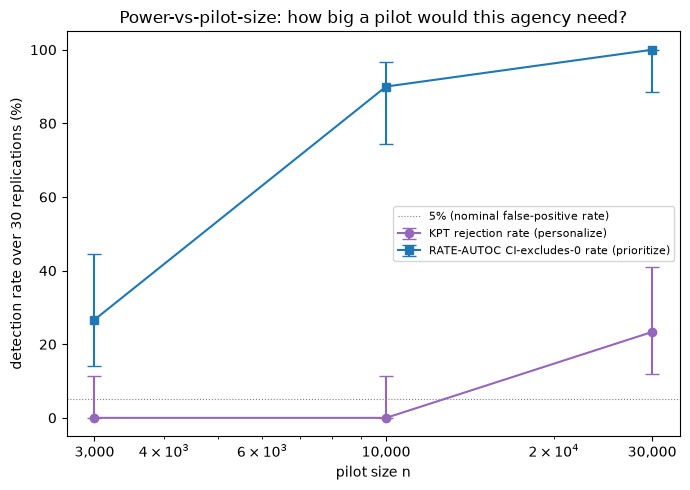

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
_ns_arr = np.array(POWER_NS)
_kpt_mid = [POWER_RESULTS[n]["kpt_rate"][1] * 100 for n in POWER_NS]
_kpt_lo = [POWER_RESULTS[n]["kpt_rate"][0] * 100 for n in POWER_NS]
_kpt_hi = [POWER_RESULTS[n]["kpt_rate"][2] * 100 for n in POWER_NS]
_rate_mid = [POWER_RESULTS[n]["rate_rate"][1] * 100 for n in POWER_NS]
_rate_lo = [POWER_RESULTS[n]["rate_rate"][0] * 100 for n in POWER_NS]
_rate_hi = [POWER_RESULTS[n]["rate_rate"][2] * 100 for n in POWER_NS]

ax.errorbar(_ns_arr, _kpt_mid, yerr=[np.array(_kpt_mid) - np.array(_kpt_lo), np.array(_kpt_hi) - np.array(_kpt_mid)],
            fmt="o-", color=PALETTE["llm_score"], capsize=5, label="KPT rejection rate (personalize)")
ax.errorbar(_ns_arr, _rate_mid, yerr=[np.array(_rate_mid) - np.array(_rate_lo), np.array(_rate_hi) - np.array(_rate_mid)],
            fmt="s-", color=PALETTE["rule_score"], capsize=5, label="RATE-AUTOC CI-excludes-0 rate (prioritize)")
ax.set_xscale("log")
ax.set_xticks(POWER_NS)
ax.set_xticklabels([f"{n:,}" for n in POWER_NS])
ax.set_xlabel("pilot size n")
ax.set_ylabel("detection rate over 30 replications (%)")
ax.set_ylim(-5, 105)
ax.axhline(5, color="gray", linestyle=":", linewidth=0.8, label="5% (nominal false-positive rate)")
ax.set_title("Power-vs-pilot-size: how big a pilot would this agency need?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Cost and what the three papers buy

Every DeepSeek call this project made (whether it was a live call or a cache hit) is recorded in
`USAGE_LEDGER` (Notebook 2's fit-scoring calls, section `"llm_fit"`, plus this notebook's pretest calls,
section `"pretest_surrogacy"`), so the cost figures below are what the *work* costs, not just what this
particular re-run happened to spend live. Setter-call costs are **derived here; predeclared assumptions**
-- none of the three papers price a human phone call or an email pilot; they only supply the statistical
machinery for deciding *whether* the money was well spent.


In [24]:
# --- LLM cost: fit-scoring (Notebook 2) + pretest (this notebook), from the shared USAGE_LEDGER ---
_fit_entries = [e for e in USAGE_LEDGER if e["section"] == "llm_fit"]
_pretest_entries = [e for e in USAGE_LEDGER if e["section"] == "pretest_surrogacy"]
_cost_fit_peak = ledger_cost_usd(_fit_entries, peak=True)
_cost_fit_offpeak = ledger_cost_usd(_fit_entries, peak=False)
_cost_pretest_peak = ledger_cost_usd(_pretest_entries, peak=True)
_cost_pretest_offpeak = ledger_cost_usd(_pretest_entries, peak=False)
print(f"[S5.1] LLM fit-scoring cost (Notebook 2, {len(_fit_entries)} ledger entries, {LLM_SUBSET_N} leads): "
      f"${_cost_fit_peak:.4f} peak / ${_cost_fit_offpeak:.4f} off-peak "
      f"(${_cost_fit_peak/LLM_SUBSET_N*1000:.3f} peak per 1,000 leads scored)")
print(f"[S5.2] LLM pretest cost (this notebook, {len(_pretest_entries)} ledger entries, "
      f"{len(_ALL_UNITS)} units x K={K_DRAWS} draws): ${_cost_pretest_peak:.4f} peak / "
      f"${_cost_pretest_offpeak:.4f} off-peak")

# --- Setter-call cost assumptions (derived here; predeclared) ---
ASSUMED_MINUTES_PER_CALL = 4.0     # avg minutes per setter call attempt, incl. no-answers (derived here; predeclared)
ASSUMED_SETTER_HOURLY = 22.0       # fully-loaded hourly cost of a setter, USD (derived here; predeclared)
ASSUMED_COST_PER_CALL = ASSUMED_MINUTES_PER_CALL / 60.0 * ASSUMED_SETTER_HOURLY
print(f"[S5.3] (derived here; predeclared) assumed setter cost = {ASSUMED_MINUTES_PER_CALL} min/call @ "
      f"${ASSUMED_SETTER_HOURLY}/hr = ${ASSUMED_COST_PER_CALL:.2f} per call attempt")

# --- Booked calls per $ at 20% setter capacity: current system (rule_fit) vs the RATE-chosen candidate.
# oracle_true_uplift is EXCLUDED here on purpose -- it is simulator-only ground truth, never available to
# an operator, so it is not a deployable candidate (audit fix: previously implied as a 3-way choice). ---
_deployable = {k: v for k, v in RATE_A.items() if k != "oracle_true_uplift"}
_best_deployable_name = max(_deployable, key=lambda k: _deployable[k]["toc20"])
_n_call_capacity = int(CAPACITY * len(PILOT_TEST))
_setter_spend = _n_call_capacity * ASSUMED_COST_PER_CALL
print(f"\n[S5.4] booked calls per $ at {int(CAPACITY*100)}% capacity ({_n_call_capacity} calls, "
      f"${_setter_spend:,.0f} setter spend, TEST half, deployable rules only):")
for name, d in _deployable.items():
    extra_calls = CAPACITY * d["toc20"] * len(PILOT_TEST)
    per_dollar = extra_calls / _setter_spend if _setter_spend else float("nan")
    tag = " <- RATE-chosen (highest estimated TOC(0.2))" if name == _best_deployable_name else ""
    print(f"      {name}: extra booked calls (vs random targeting) = {extra_calls:+.1f}, "
          f"= {per_dollar:+.5f} extra bookings per $ of setter spend{tag}")

# --- Human pilot vs LLM pretest cost, for the pretest→prioritize→personalize chain's first step ---
_human_pilot_n = _PRETEST_N_PER_SAMPLE  # the 200 P=0 human leads this pretest's calibration relies on
_human_pilot_cost = _human_pilot_n * ASSUMED_C_PER_UNIT  # ASSUMED_C_PER_UNIT from the pilot-size cell above
print(f"\n[S5.5] cost of the human pilot data this pretest's calibration needs ({_human_pilot_n} leads x "
      f"${ASSUMED_C_PER_UNIT}/unit, derived here; predeclared) = ${_human_pilot_cost:.2f}, vs. "
      f"LLM pretest cost [S5.2] = ${_cost_pretest_peak:.4f} peak -- "
      "the LLM pretest is far cheaper per run, but it only has standing to replace "
      "part of the human pilot (comparing NEW template variants) if the falsification test above passed; "
      "it still needs SOME human P=0 data to calibrate against in the first place.")


[S5.1] LLM fit-scoring cost (Notebook 2, 30 ledger entries, 600 leads): $0.0292 peak / $0.0146 off-peak ($0.049 peak per 1,000 leads scored)
[S5.2] LLM pretest cost (this notebook, 61 ledger entries, 400 units x K=3 draws): $0.0527 peak / $0.0263 off-peak
[S5.3] (derived here; predeclared) assumed setter cost = 4.0 min/call @ $22.0/hr = $1.47 per call attempt

[S5.4] booked calls per $ at 20% capacity (300 calls, $440 setter spend, TEST half, deployable rules only):
      rule_fit: extra booked calls (vs random targeting) = -31.0, = -0.07039 extra bookings per $ of setter spend
      learned_uplift: extra booked calls (vs random targeting) = -2.0, = -0.00459 extra bookings per $ of setter spend <- RATE-chosen (highest estimated TOC(0.2))

[S5.5] cost of the human pilot data this pretest's calibration needs (200 leads x $0.02/unit, derived here; predeclared) = $4.00, vs. LLM pretest cost [S5.2] = $0.0527 peak -- the LLM pretest is far cheaper per run, but per  it only has standing to re

## Not built yet -- your call

None of the three papers decide these for you; each is a real decision the human running this project
would still have to make before deploying anything built here:

- **Whether the real historical data is randomized.** If the agency's actual setter-call/email history is
 observational, RATE needs Eq. 2.12 (estimated propensities, unconfoundedness) instead of the known-π form
 used throughout this notebook, and KPT's known-propensity assumption (Assumption 3) would need re-checking
 too. *Decide: audit the real CRM export for how calls/templates were actually assigned before reusing any
 of this code as-is.*
- **The ICP prompt.** `FIT_SYSTEM_PROMPT` (Notebook 2) and `PRETEST_SYSTEM_PROMPT` (this notebook) are both
 written from this project's own guess at the agency's ideal-customer profile. *Decide: replace both with
 the agency's actual sales criteria and persona-simulation intent before trusting any score they produce.*
- **Capacity and budget constraints.** The setter-capacity fraction (`CAPACITY = 0.2` above) and the cost
 assumptions in Section 5 are placeholders; none of the three papers formalize a budget-constrained
 targeting problem. *Decide: what the agency's actual weekly setter capacity and per-call cost really are,
 and whether a formal budget-constrained variant of RATE is worth building (see the Budget-Constrained
 Causal Bandits runner-up in the README).*
- **Adaptive or continuous campaigns.** All three papers assume offline, non-adaptive data collected once
 and analyzed once; none license re-scoring leads or updating a policy on a rolling basis. *Decide: if the
 agency wants continuous/adaptive targeting, that is a different (and harder) statistical problem than
 anything built here.*
- **Interference between leads.** SUTVA is assumed throughout -- one realtor's call or email is assumed not
 to affect another's outcome. Realtors in the same brokerage or local market plausibly violate this.
 *Decide: whether brokerage- or market-level clustering needs to be modeled or at least checked for.*
- **Multiple testing across the three steps.** Pretest, prioritize, and personalize are each run and
 interpreted as its own test in this notebook; chaining them (as this project's own design does) is not
 covered by any of the three papers, which is q12's explicit gap. *Decide: whether a joint error-rate
 correction across the chain is worth the statistical complexity, given the pilot sizes here already
 struggle for power one test at a time.*
- **Rare-event outcomes.** Booked *deals* (as opposed to booked *calls*) are almost certainly a much rarer
 event than anything modeled here, and none of the three papers' asymptotics target extreme class
 imbalance. *Decide: whether deals (not just calls/replies) need a different statistical approach entirely
 before this pipeline is extended that far down the funnel.*
- **Pilot-to-deployment shift.** Proposition 4's sensitivity bound (Section 5 of Notebook 1, Section 2 of
 this notebook) only covers a *measured* overlap violation between two known samples -- it says nothing
 about unmeasured drift between a pilot cohort and a future deployment cohort. *Decide: how the agency
 would monitor for that drift once a rule is actually shipped.*
- **LLM surrogates inside RATE or KPT.** This project keeps LLM-surrogate outcomes strictly out of the RATE
 and KPT machinery -- both only ever run on human/simulated-human outcomes. Using an
 LLM surrogate *inside* a RATE or KPT evaluation is not stated in any of the three sources. *Decide: this
 is a genuine research gap, not an engineering choice -- do not build it without new theory or a very
 large calibration sample to justify it empirically.*
- **Deliverability and compliance.** CAN-SPAM (email) and TCPA (calls) obligations are entirely outside the
 scope of all three papers and this notebook. *Decide: compliance review needs to happen before any of this
 touches real leads, independent of anything the statistics say.*
